In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import mne

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

CHB02_DIR = (
    DATA_DIR /
    "multi_patient" /
    "chb02"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nCHB02 directory:")
print(CHB02_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project root:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection

CHB02 directory:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02

Model directory:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models


In [2]:
MODEL_PATH = (
    MODEL_DIR /
    "random_forest_final.pkl"
)

model = joblib.load(
    MODEL_PATH
)

print("Model loaded successfully!")
print(model)

Model loaded successfully!
RandomForestClassifier(n_jobs=-1, random_state=42)


In [3]:
# ============================================================
# CELL 3 — CHB02 SEIZURE ANNOTATIONS
# ============================================================

CHB02_SEIZURE_ANNOTATIONS = {
    "chb02_16.edf": [(130, 212)],
    "chb02_16+.edf": [(2972, 3053)],
    "chb02_19.edf": [(3369, 3378)]
}

print("CHB02 Seizure Annotations")

for file, intervals in CHB02_SEIZURE_ANNOTATIONS.items():
    print(f"{file}: {intervals}")

CHB02 Seizure Annotations
chb02_16.edf: [(130, 212)]
chb02_16+.edf: [(2972, 3053)]
chb02_19.edf: [(3369, 3378)]


In [4]:
# ============================================================
# CELL 4 — DEFINE FREQUENCY BANDS AND FEATURES
# ============================================================

from scipy.signal import welch

WINDOW_SIZE = 4

frequency_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40)
}

feature_names = [
    "Mean",
    "Std",
    "Variance",
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma"
]

print("Window size:", WINDOW_SIZE, "seconds")

print("\nFrequency bands:")
for name, band in frequency_bands.items():
    print(name, ":", band)

print("\nFeatures:")
print(feature_names)

Window size: 4 seconds

Frequency bands:
Delta : (0.5, 4)
Theta : (4, 8)
Alpha : (8, 13)
Beta : (13, 30)
Gamma : (30, 40)

Features:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']


In [5]:
# ============================================================
# CELL 5 — FEATURE EXTRACTION FUNCTIONS
# ============================================================

def preprocess_signal(raw):

    processed = raw.copy()

    processed.filter(
        l_freq=0.5,
        h_freq=40,
        verbose=False
    )

    return processed


def extract_statistical_features(window):

    channel_means = np.mean(
        window,
        axis=1
    )

    channel_stds = np.std(
        window,
        axis=1
    )

    channel_variances = np.var(
        window,
        axis=1
    )

    return [
        np.mean(channel_means),
        np.mean(channel_stds),
        np.mean(channel_variances)
    ]


def extract_frequency_features(window, sfreq):

    channel_band_powers = []

    for channel in window:

        frequencies, psd = welch(
            channel,
            fs=sfreq,
            nperseg=512
        )

        band_powers = []

        for low_freq, high_freq in frequency_bands.values():

            mask = (
                (frequencies >= low_freq) &
                (frequencies < high_freq)
            )

            power = np.trapezoid(
                psd[mask],
                frequencies[mask]
            )

            band_powers.append(power)

        channel_band_powers.append(
            band_powers
        )

    return np.mean(
        channel_band_powers,
        axis=0
    )


def extract_window_features(window, sfreq):

    statistical_features = (
        extract_statistical_features(window)
    )

    frequency_features = (
        extract_frequency_features(
            window,
            sfreq
        )
    )

    features = np.concatenate([
        statistical_features,
        frequency_features
    ])

    return features


print("Feature extraction functions created successfully!")
print("Total expected features:", len(feature_names))

Feature extraction functions created successfully!
Total expected features: 8


In [6]:
# ============================================================
# CELL 6 — BUILD CHB02 FEATURE DATASET
# ============================================================

edf_files = sorted(
    CHB02_DIR.glob("*.edf")
)

print("CHB02 EDF files found:", len(edf_files))

for file in edf_files:
    print(" -", file.name)

all_features = []
all_labels = []
all_metadata = []

for file_path in edf_files:

    print("\nProcessing:", file_path.name)

    # --------------------------------------------------------
    # Read EDF
    # --------------------------------------------------------
    raw = mne.io.read_raw_edf(
        file_path,
        preload=True,
        verbose=False
    )

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------
    processed_raw = preprocess_signal(raw)

    data = processed_raw.get_data()
    sfreq = processed_raw.info["sfreq"]

    samples_per_window = int(
        WINDOW_SIZE * sfreq
    )

    total_samples = data.shape[1]

    # --------------------------------------------------------
    # Get seizure annotations
    # --------------------------------------------------------
    seizure_intervals = (
        CHB02_SEIZURE_ANNOTATIONS.get(
            file_path.name,
            []
        )
    )

    file_windows = 0
    file_seizure_windows = 0

    # --------------------------------------------------------
    # Create 4-second windows
    # --------------------------------------------------------
    for start_sample in range(
        0,
        total_samples - samples_per_window + 1,
        samples_per_window
    ):

        end_sample = (
            start_sample +
            samples_per_window
        )

        window_start = (
            start_sample / sfreq
        )

        window_end = (
            end_sample / sfreq
        )

        window = data[
            :,
            start_sample:end_sample
        ]

        # Default = normal
        label = 0

        # ----------------------------------------------------
        # Check seizure overlap
        # ----------------------------------------------------
        for seizure_start, seizure_end in seizure_intervals:

            if (
                window_start < seizure_end
                and window_end > seizure_start
            ):
                label = 1
                break

        # ----------------------------------------------------
        # Extract 8 features
        # ----------------------------------------------------
        window_features = extract_window_features(
            window,
            sfreq
        )

        all_features.append(
            window_features
        )

        all_labels.append(label)

        all_metadata.append({
            "patient": "chb02",
            "file": file_path.name,
            "window_start": window_start,
            "window_end": window_end,
            "label": label
        })

        file_windows += 1

        if label == 1:
            file_seizure_windows += 1

    print("Windows:", file_windows)
    print(
        "Seizure Windows:",
        file_seizure_windows
    )


# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

chb02_features = np.array(
    all_features
)

chb02_labels = np.array(
    all_labels
)

chb02_metadata = pd.DataFrame(
    all_metadata
)

chb02_features_df = pd.DataFrame(
    chb02_features,
    columns=feature_names
)

chb02_features_df["Label"] = (
    chb02_labels
)

print("\n========================================")
print("CHB02 DATASET CREATED")
print("========================================")

print(
    "Feature Matrix Shape:",
    chb02_features.shape
)

print(
    "Labels Shape:",
    chb02_labels.shape
)

print(
    "Metadata Shape:",
    chb02_metadata.shape
)

print(
    "\nNormal Windows:",
    np.sum(chb02_labels == 0)
)

print(
    "Seizure Windows:",
    np.sum(chb02_labels == 1)
)

print("\nSeizure Windows by File:")

print(
    chb02_metadata[
        chb02_metadata["label"] == 1
    ]["file"].value_counts()
)

CHB02 EDF files found: 8
 - chb02_01.edf
 - chb02_02.edf
 - chb02_03.edf
 - chb02_04.edf
 - chb02_05.edf
 - chb02_16+.edf
 - chb02_16.edf
 - chb02_19.edf

Processing: chb02_01.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_7420\610260111.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Windows: 900
Seizure Windows: 0

Processing: chb02_02.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_7420\610260111.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Windows: 900
Seizure Windows: 0

Processing: chb02_03.edf


...

Windows: 900
Seizure Windows: 21

Processing: chb02_16.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_7420\610260111.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Windows: 239
Seizure Windows: 21

Processing: chb02_19.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_7420\610260111.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Windows: 900
Seizure Windows: 3

CHB02 DATASET CREATED
Feature Matrix Shape: (6539, 8)
Labels Shape: (6539,)
Metadata Shape: (6539, 5)

Normal Windows: 6494
Seizure Windows: 45

Seizure Windows by File:
file
chb02_16+.edf    21
chb02_16.edf     21
chb02_19.edf      3
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 7 — CREATE AND SAVE CHB02 FEATURE DATASET
# ============================================================

CHB02_FEATURES_PATH = CHB02_DIR / "features.csv"
CHB02_METADATA_PATH = CHB02_DIR / "window_metadata.csv"

# Convert collected data into final arrays
chb02_features = np.array(all_features)
chb02_labels = np.array(all_labels)

chb02_metadata = pd.DataFrame(all_metadata)

# Create feature DataFrame
chb02_features_df = pd.DataFrame(
    chb02_features,
    columns=feature_names
)

# Add labels
chb02_features_df["Label"] = chb02_labels

# Save features
chb02_features_df.to_csv(
    CHB02_FEATURES_PATH,
    index=False
)

# Save metadata
chb02_metadata.to_csv(
    CHB02_METADATA_PATH,
    index=False
)

# ============================================================
# VERIFICATION
# ============================================================

print("========================================")
print("CHB02 DATASET SAVED")
print("========================================")

print("\nFeatures:", CHB02_FEATURES_PATH)
print("Metadata:", CHB02_METADATA_PATH)

print("\nFeature file exists:",
      CHB02_FEATURES_PATH.exists())

print("Metadata file exists:",
      CHB02_METADATA_PATH.exists())

print("\nFeatures shape:",
      chb02_features_df.shape)

print("Metadata shape:",
      chb02_metadata.shape)

print("\nClass distribution:")
print(
    chb02_features_df["Label"]
    .value_counts()
    .sort_index()
)

CHB02 DATASET SAVED

Features: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\features.csv
Metadata: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\window_metadata.csv

Feature file exists: True
Metadata file exists: True

Features shape: (6539, 9)
Metadata shape: (6539, 5)

Class distribution:
Label
0    6494
1      45
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 8 — LOAD CHB02 DATASET FOR CROSS-PATIENT TESTING
# ============================================================

# Load CHB02 features
chb02_test_df = pd.read_csv(CHB02_FEATURES_PATH)

# Separate features and labels
X_chb02 = chb02_test_df[feature_names].values
y_chb02 = chb02_test_df["Label"].values

print("========================================")
print("CHB02 CROSS-PATIENT TEST DATA")
print("========================================")

print("\nFeature shape:", X_chb02.shape)
print("Label shape:", y_chb02.shape)

print("\nClass distribution:")
print(
    pd.Series(y_chb02)
    .value_counts()
    .sort_index()
)

print("\nFeature columns:")
print(feature_names)

CHB02 CROSS-PATIENT TEST DATA

Feature shape: (6539, 8)
Label shape: (6539,)

Class distribution:
0    6494
1      45
Name: count, dtype: int64

Feature columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']


In [9]:
# ============================================================
# CELL 9 — CROSS-PATIENT PREDICTION ON CHB02
# ============================================================

# Predict CHB02 using the CHB01-trained model
y_pred_chb02 = model.predict(X_chb02)

print("========================================")
print("CHB02 CROSS-PATIENT PREDICTION")
print("========================================")

print("\nActual class counts:")
print(pd.Series(y_chb02).value_counts().sort_index())

print("\nPredicted class counts:")
print(pd.Series(y_pred_chb02).value_counts().sort_index())

print("\nTotal predictions:", len(y_pred_chb02))

CHB02 CROSS-PATIENT PREDICTION

Actual class counts:
0    6494
1      45
Name: count, dtype: int64

Predicted class counts:
0    6532
1       7
Name: count, dtype: int64

Total predictions: 6539


In [10]:
# ============================================================
# CELL 10 — CHB02 CROSS-PATIENT EVALUATION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion matrix
cm = confusion_matrix(
    y_chb02,
    y_pred_chb02
)

tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(
    y_chb02,
    y_pred_chb02
)

precision = precision_score(
    y_chb02,
    y_pred_chb02,
    zero_division=0
)

sensitivity = recall_score(
    y_chb02,
    y_pred_chb02,
    zero_division=0
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_chb02,
    y_pred_chb02,
    zero_division=0
)

print("========================================")
print("CHB02 CROSS-PATIENT EVALUATION")
print("========================================")

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\n----------------------------------------")
print("PERFORMANCE METRICS")
print("----------------------------------------")

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")

print("\n----------------------------------------")
print("CLASSIFICATION REPORT")
print("----------------------------------------")

print(
    classification_report(
        y_chb02,
        y_pred_chb02,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

CHB02 CROSS-PATIENT EVALUATION

Confusion Matrix:
[[6490    4]
 [  42    3]]

True Negatives : 6490
False Positives: 4
False Negatives: 42
True Positives : 3

----------------------------------------
PERFORMANCE METRICS
----------------------------------------
Accuracy    : 0.9930
Precision   : 0.4286
Sensitivity : 0.0667
Specificity : 0.9994
F1 Score    : 0.1154

----------------------------------------
CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      6494
     Seizure       0.43      0.07      0.12        45

    accuracy                           0.99      6539
   macro avg       0.71      0.53      0.56      6539
weighted avg       0.99      0.99      0.99      6539



In [11]:
# ============================================================
# CELL — THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Get probability of seizure class
y_prob = model.predict_proba(X_chb02)[:, 1]

print("========================================")
print("CHB02 THRESHOLD ANALYSIS")
print("========================================")

print("\nProbability statistics:")
print("Minimum :", y_prob.min())
print("Maximum :", y_prob.max())
print("Mean    :", y_prob.mean())
print("Median  :", np.median(y_prob))

print("\nActual seizure probabilities:")
print(
    np.sort(y_prob[y_chb02 == 1])[-20:]
)

print("\nThreshold comparison")
print("----------------------------------------")

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05
]

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_chb02,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    f1 = (
        f1_score(
            y_chb02,
            y_pred_threshold,
            zero_division=0
        )
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    print(
        f"\nThreshold = {threshold:.2f}"
    )

    print(
        f"TP={tp}, FP={fp}, TN={tn}, FN={fn}"
    )

    print(
        f"Sensitivity : {sensitivity:.4f}"
    )

    print(
        f"Precision   : {precision:.4f}"
    )

    print(
        f"Specificity : {specificity:.4f}"
    )

    print(
        f"F1 Score    : {f1:.4f}"
    )

CHB02 THRESHOLD ANALYSIS

Probability statistics:
Minimum : 0.0
Maximum : 0.73
Mean    : 0.012225110873222205
Median  : 0.0

Actual seizure probabilities:
[0.18 0.18 0.21 0.21 0.21 0.23 0.25 0.27 0.29 0.31 0.35 0.36 0.39 0.4
 0.4  0.44 0.45 0.51 0.52 0.56]

Threshold comparison
----------------------------------------

Threshold = 0.50
TP=3, FP=4, TN=6490, FN=42
Sensitivity : 0.0667
Precision   : 0.4286
Specificity : 0.9994
F1 Score    : 0.1154

Threshold = 0.40
TP=7, FP=9, TN=6485, FN=38
Sensitivity : 0.1556
Precision   : 0.4375
Specificity : 0.9986
F1 Score    : 0.2295

Threshold = 0.30
TP=11, FP=36, TN=6458, FN=34
Sensitivity : 0.2444
Precision   : 0.2340
Specificity : 0.9945
F1 Score    : 0.2391

Threshold = 0.20
TP=18, FP=95, TN=6399, FN=27
Sensitivity : 0.4000
Precision   : 0.1593
Specificity : 0.9854
F1 Score    : 0.2278

Threshold = 0.10
TP=26, FP=230, TN=6264, FN=19
Sensitivity : 0.5778
Precision   : 0.1016
Specificity : 0.9646
F1 Score    : 0.1728

Threshold = 0.05
TP=30, FP=

In [55]:
# ============================================================
# CELL — LOAD CHB01 AND CHB02 FEATURES FOR DISTRIBUTION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("========================================")
print("FEATURE DISTRIBUTION SHIFT ANALYSIS")
print("========================================")

# ------------------------------------------------------------
# 1. Define feature paths
# ------------------------------------------------------------

CHB01_FEATURES_PATH = (
    DATA_DIR /
    "chb01" /
    "features.csv"
)

CHB02_FEATURES_PATH = (
    CHB02_DIR /
    "features.csv"
)

print("\nCHB01 feature file:")
print(CHB01_FEATURES_PATH)

print("\nCHB02 feature file:")
print(CHB02_FEATURES_PATH)

# ------------------------------------------------------------
# 2. Check files
# ------------------------------------------------------------

print("\nFile existence:")

print(
    "CHB01:",
    CHB01_FEATURES_PATH.exists()
)

print(
    "CHB02:",
    CHB02_FEATURES_PATH.exists()
)

# ------------------------------------------------------------
# 3. Load datasets
# ------------------------------------------------------------

chb01_df = pd.read_csv(
    CHB01_FEATURES_PATH
)

chb02_df = pd.read_csv(
    CHB02_FEATURES_PATH
)

# ------------------------------------------------------------
# 4. Display shapes
# ------------------------------------------------------------

print("\nDataset shapes:")

print(
    "CHB01:",
    chb01_df.shape
)

print(
    "CHB02:",
    chb02_df.shape
)

# ------------------------------------------------------------
# 5. Display feature columns
# ------------------------------------------------------------

print("\nCHB01 columns:")
print(chb01_df.columns.tolist())

print("\nCHB02 columns:")
print(chb02_df.columns.tolist())

# ------------------------------------------------------------
# 6. Class distributions
# ------------------------------------------------------------

print("\n========================================")
print("CLASS DISTRIBUTION")
print("========================================")

print("\nCHB01:")
print(
    chb01_df["Label"]
    .value_counts()
    .sort_index()
)

print("\nCHB02:")
print(
    chb02_df["Label"]
    .value_counts()
    .sort_index()
)

print("\n========================================")
print("DATASETS LOADED SUCCESSFULLY")
print("========================================")

FEATURE DISTRIBUTION SHIFT ANALYSIS

CHB01 feature file:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\chb01\features.csv

CHB02 feature file:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\features.csv

File existence:
CHB01: False
CHB02: True


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Prajapati_Shivam\\EEG-Seizure-Detection\\data\\chb01\\features.csv'

In [13]:
# ============================================================
# CELL 2 — LOCATE CHB01 FEATURE FILE
# ============================================================

print("========================================")
print("SEARCHING FOR CHB01 FEATURE FILE")
print("========================================")

# Search the entire data directory
feature_files = list(DATA_DIR.rglob("features.csv"))

print("\nFeature files found:")

for path in feature_files:
    print(" -", path)

print("\nTotal features.csv files found:", len(feature_files))

# ------------------------------------------------------------
# Identify CHB01 feature files
# ------------------------------------------------------------

chb01_feature_files = [
    path
    for path in feature_files
    if "chb01" in str(path).lower()
]

print("\n========================================")
print("CHB01 FEATURE FILES")
print("========================================")

if chb01_feature_files:
    for path in chb01_feature_files:
        print("FOUND:", path)
else:
    print("NO CHB01 features.csv FOUND.")

SEARCHING FOR CHB01 FEATURE FILE

Feature files found:
 - C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\features.csv
 - C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\features.csv

Total features.csv files found: 2

CHB01 FEATURE FILES
NO CHB01 features.csv FOUND.


In [14]:
# ============================================================
# CELL 3 — LOAD CHB01 AND CHB02 FEATURES
# ============================================================

CHB01_FEATURES_PATH = DATA_DIR / "features.csv"
CHB02_FEATURES_PATH = CHB02_DIR / "features.csv"

print("========================================")
print("LOADING CHB01 AND CHB02 FEATURES")
print("========================================")

print("\nCHB01:")
print(CHB01_FEATURES_PATH)

print("\nCHB02:")
print(CHB02_FEATURES_PATH)

print("\nFile existence:")
print("CHB01:", CHB01_FEATURES_PATH.exists())
print("CHB02:", CHB02_FEATURES_PATH.exists())

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

chb01_df = pd.read_csv(CHB01_FEATURES_PATH)
chb02_df = pd.read_csv(CHB02_FEATURES_PATH)

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("\n========================================")
print("DATASET INFORMATION")
print("========================================")

print("\nCHB01 shape:", chb01_df.shape)
print("CHB02 shape:", chb02_df.shape)

print("\nCHB01 columns:")
print(chb01_df.columns.tolist())

print("\nCHB02 columns:")
print(chb02_df.columns.tolist())

print("\n========================================")
print("CLASS DISTRIBUTION")
print("========================================")

print("\nCHB01:")
print(chb01_df["Label"].value_counts().sort_index())

print("\nCHB02:")
print(chb02_df["Label"].value_counts().sort_index())

print("\n========================================")
print("DATASETS LOADED SUCCESSFULLY")
print("========================================")

LOADING CHB01 AND CHB02 FEATURES

CHB01:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\features.csv

CHB02:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\features.csv

File existence:
CHB01: True
CHB02: True

DATASET INFORMATION

CHB01 shape: (13181, 9)
CHB02 shape: (6539, 9)

CHB01 columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma', 'Label']

CHB02 columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma', 'Label']

CLASS DISTRIBUTION

CHB01:
Label
0    13080
1      101
Name: count, dtype: int64

CHB02:
Label
0    6494
1      45
Name: count, dtype: int64

DATASETS LOADED SUCCESSFULLY


In [16]:
# ============================================================
# CELL 4 — CHB01 vs CHB02 FEATURE STATISTICS
# ============================================================

feature_names = [
    "Mean",
    "Std",
    "Variance",
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma"
]

print("========================================")
print("CHB01 vs CHB02 FEATURE STATISTICS")
print("========================================")

# Calculate mean and standard deviation
chb01_stats = chb01_df[feature_names].agg(["mean", "std"]).T
chb02_stats = chb02_df[feature_names].agg(["mean", "std"]).T

# Create comparison table
comparison_df = pd.DataFrame({
    "CHB01_Mean": chb01_stats["mean"],
    "CHB02_Mean": chb02_stats["mean"],
    "CHB01_Std": chb01_stats["std"],
    "CHB02_Std": chb02_stats["std"]
})

print("\nFeature statistics comparison:")
display(comparison_df)

print("\n========================================")
print("MEAN DIFFERENCE")
print("========================================")

comparison_df["Absolute_Mean_Difference"] = abs(
    comparison_df["CHB01_Mean"] -
    comparison_df["CHB02_Mean"]
)

display(
    comparison_df[
        ["CHB01_Mean", "CHB02_Mean", "Absolute_Mean_Difference"]
    ]
)

print("\nFeature distribution comparison completed.")

CHB01 vs CHB02 FEATURE STATISTICS

Feature statistics comparison:


,CHB01_Mean,CHB02_Mean,CHB01_Std,CHB02_Std
Mean,1.078800e-09,3.073973e-09,8.633696e-07,8.037991e-07
Std,3.360592e-05,4.220444e-05,1.560672e-05,3.054575e-05
Variance,1.632981e-09,3.295919e-09,2.070696e-09,1.383123e-08
Delta,1.038680e-09,1.540347e-09,1.441385e-09,6.985536e-09
Theta,1.888265e-10,3.653989e-10,3.078467e-10,2.619625e-09
Alpha,7.108513e-11,1.836868e-10,1.484210e-10,1.312184e-09
Beta,7.534000e-11,4.679168e-10,2.056258e-10,1.497357e-09
Gamma,3.356445e-11,2.865377e-10,8.794154e-11,5.728179e-10



MEAN DIFFERENCE


,CHB01_Mean,CHB02_Mean,Absolute_Mean_Difference
Mean,1.078800e-09,3.073973e-09,1.995173e-09
Std,3.360592e-05,4.220444e-05,8.598524e-06
Variance,1.632981e-09,3.295919e-09,1.662937e-09
Delta,1.038680e-09,1.540347e-09,5.016666e-10
Theta,1.888265e-10,3.653989e-10,1.765724e-10
Alpha,7.108513e-11,1.836868e-10,1.126017e-10
Beta,7.534000e-11,4.679168e-10,3.925768e-10
Gamma,3.356445e-11,2.865377e-10,2.529732e-10



Feature distribution comparison completed.


In [18]:
from pathlib import Path

IMAGES_DIR = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images"
)

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Images directory:")
print(IMAGES_DIR)

Images directory:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images


CHB01 vs CHB02 FEATURE DISTRIBUTIONS


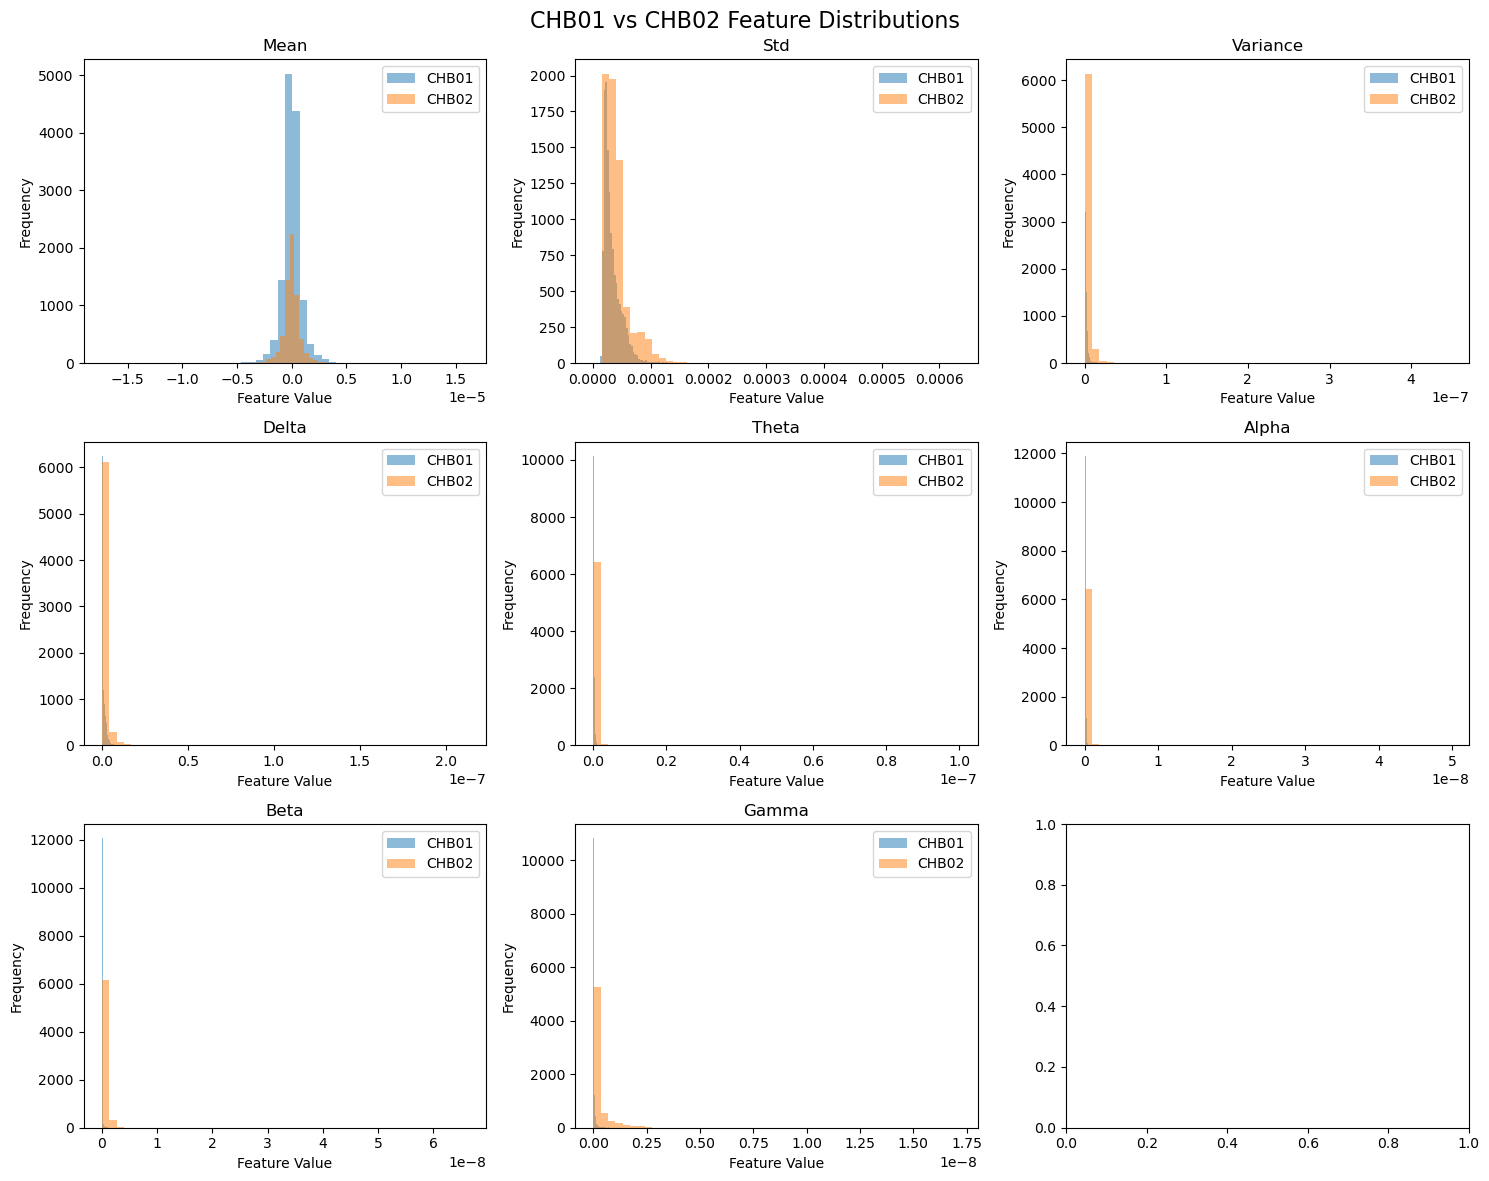


Distribution comparison completed.
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_vs_chb02_feature_distributions.png


In [19]:
# ============================================================
# CELL 5 — VISUAL FEATURE DISTRIBUTION COMPARISON
# ============================================================

import matplotlib.pyplot as plt

print("========================================")
print("CHB01 vs CHB02 FEATURE DISTRIBUTIONS")
print("========================================")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, feature in enumerate(feature_names):

    axes[i].hist(
        chb01_df[feature],
        bins=50,
        alpha=0.5,
        label="CHB01"
    )

    axes[i].hist(
        chb02_df[feature],
        bins=50,
        alpha=0.5,
        label="CHB02"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Feature Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle(
    "CHB01 vs CHB02 Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "chb01_vs_chb02_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nDistribution comparison completed.")
print(
    "Saved:",
    IMAGES_DIR / "chb01_vs_chb02_feature_distributions.png"
)

In [20]:
# ============================================================
# CELL 6 — FEATURE PERCENTILE COMPARISON
# ============================================================

import numpy as np
import pandas as pd

print("========================================")
print("CHB01 vs CHB02 FEATURE PERCENTILES")
print("========================================")

percentiles = [1, 25, 50, 75, 99]

rows = []

for feature in feature_names:

    chb01_values = chb01_df[feature].values
    chb02_values = chb02_df[feature].values

    row = {
        "Feature": feature
    }

    for p in percentiles:
        row[f"CHB01_P{p}"] = np.percentile(chb01_values, p)
        row[f"CHB02_P{p}"] = np.percentile(chb02_values, p)

    rows.append(row)

percentile_df = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3e}".format)

display(percentile_df)

print("\nPercentile comparison completed.")

CHB01 vs CHB02 FEATURE PERCENTILES


,Feature,CHB01_P1,CHB02_P1,CHB01_P25,CHB02_P25,CHB01_P50,CHB02_P50,CHB01_P75,CHB02_P75,CHB01_P99,CHB02_P99
0,Mean,-2.396e-06,-2.242e-06,-3.934e-07,-3.394e-07,8.233e-10,-3.867e-09,3.832e-07,3.400e-07,2.533e-06,2.282e-06
1,Std,1.636e-05,2.001e-05,2.238e-05,2.645e-05,2.858e-05,3.383e-05,4.066e-05,4.903e-05,8.690e-05,1.198e-04
2,Variance,2.828e-10,4.164e-10,5.405e-10,7.529e-10,9.091e-10,1.293e-09,2.000e-09,2.637e-09,1.033e-08,2.323e-08
3,Delta,1.059e-10,1.050e-10,2.569e-10,2.585e-10,4.831e-10,5.174e-10,1.292e-09,9.758e-10,7.087e-09,1.316e-08
4,Theta,3.942e-11,5.490e-11,7.918e-11,1.002e-10,1.263e-10,1.404e-10,2.169e-10,1.995e-10,1.085e-09,3.251e-09
5,Alpha,1.416e-11,1.807e-11,2.688e-11,4.708e-11,4.306e-11,6.157e-11,8.432e-11,1.003e-10,3.136e-10,1.623e-09
6,Beta,1.179e-11,1.242e-11,2.614e-11,9.041e-11,4.409e-11,1.883e-10,7.017e-11,5.937e-10,6.083e-10,2.624e-09
7,Gamma,3.147e-12,2.460e-12,6.108e-12,4.387e-11,1.136e-11,9.774e-11,2.755e-11,2.707e-10,3.942e-10,2.222e-09



Percentile comparison completed.


In [21]:
# ============================================================
# CELL 7 — CHB02 NORMAL vs SEIZURE FEATURE COMPARISON
# ============================================================

import pandas as pd
import numpy as np

print("========================================")
print("CHB02 NORMAL vs SEIZURE FEATURES")
print("========================================")

normal_df = chb02_df[chb02_df["Label"] == 0]
seizure_df = chb02_df[chb02_df["Label"] == 1]

print("Normal windows :", len(normal_df))
print("Seizure windows:", len(seizure_df))

rows = []

for feature in feature_names:

    normal_mean = normal_df[feature].mean()
    seizure_mean = seizure_df[feature].mean()

    normal_median = normal_df[feature].median()
    seizure_median = seizure_df[feature].median()

    rows.append({
        "Feature": feature,
        "Normal_Mean": normal_mean,
        "Seizure_Mean": seizure_mean,
        "Normal_Median": normal_median,
        "Seizure_Median": seizure_median
    })

chb02_class_comparison = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3e}".format)

display(chb02_class_comparison)

print("\nCHB02 normal vs seizure comparison completed.")

CHB02 NORMAL vs SEIZURE FEATURES
Normal windows : 6494
Seizure windows: 45


,Feature,Normal_Mean,Seizure_Mean,Normal_Median,Seizure_Median
0,Mean,2.268e-09,1.193e-07,-3.752e-09,-5.814e-08
1,Std,4.178e-05,1.040e-04,3.359e-05,1.091e-04
2,Variance,3.228e-09,1.305e-08,1.279e-09,1.250e-08
3,Delta,1.509e-09,6.054e-09,5.142e-10,5.106e-09
4,Theta,3.500e-10,2.583e-09,1.399e-10,2.523e-09
5,Alpha,1.784e-10,9.417e-10,6.139e-11,8.459e-10
6,Beta,4.604e-10,1.557e-09,1.859e-10,9.676e-10
7,Gamma,2.853e-10,4.623e-10,9.666e-11,2.040e-10



CHB02 normal vs seizure comparison completed.


CHB02 NORMAL vs SEIZURE DISTRIBUTIONS


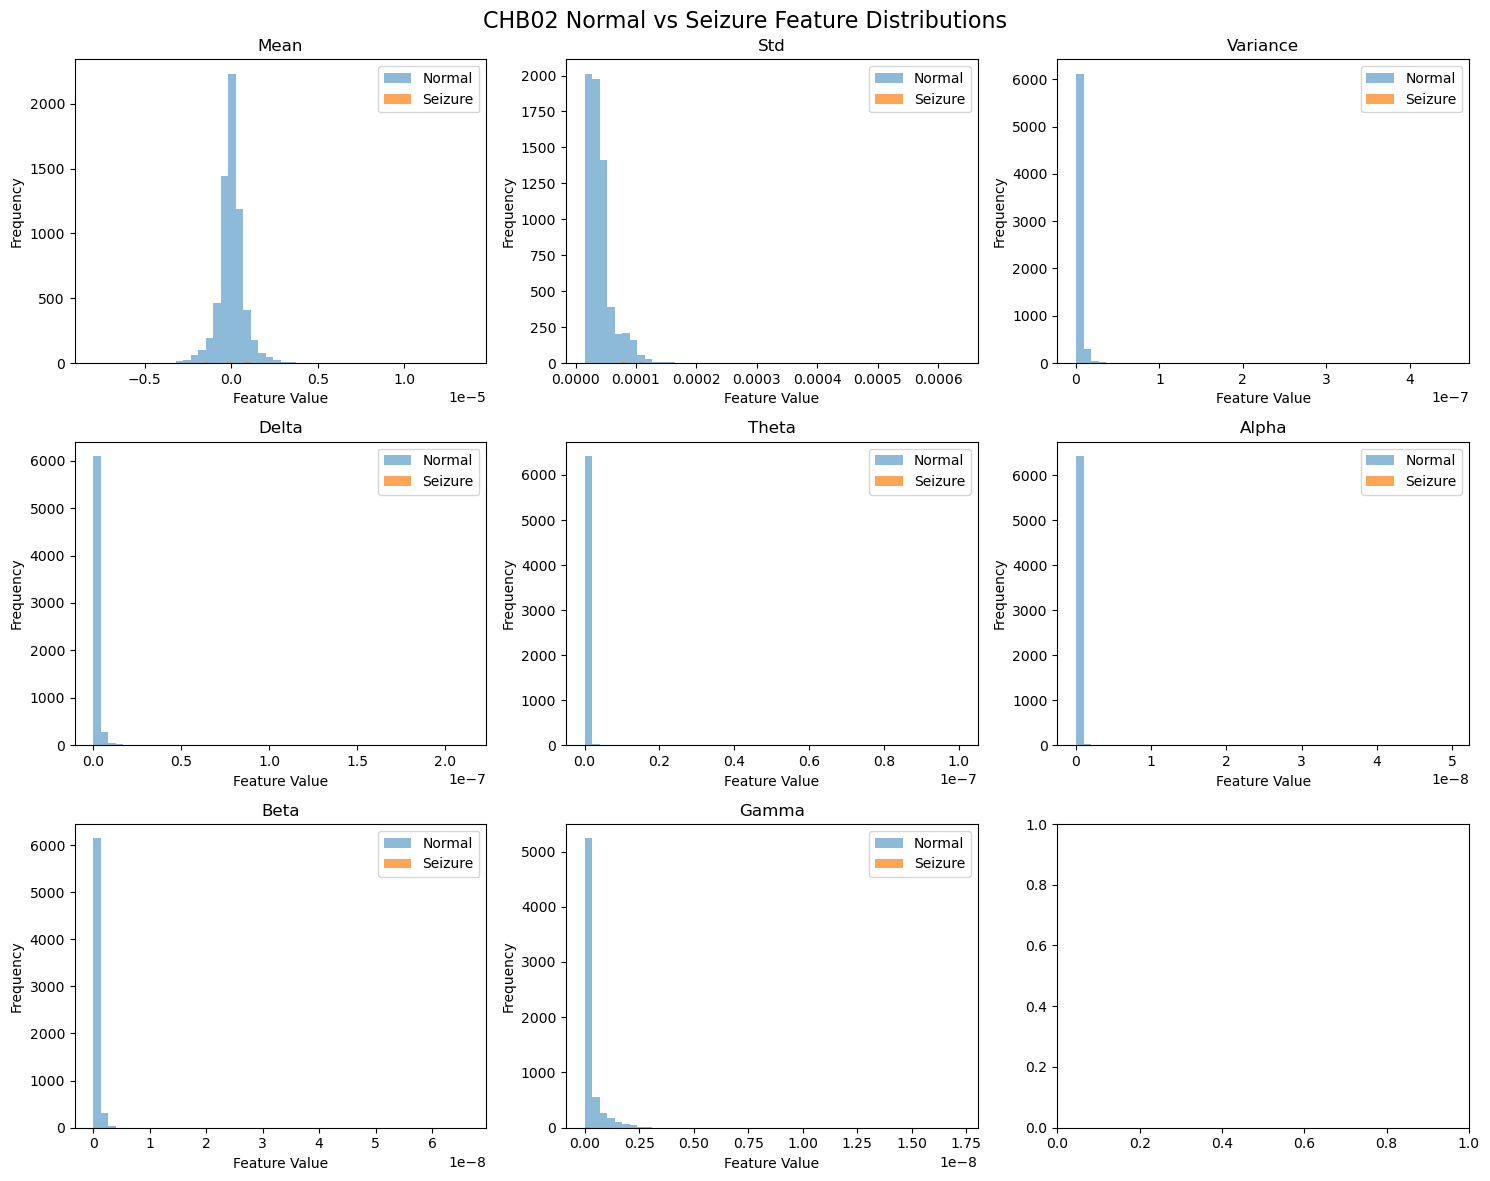


Class distribution comparison completed.
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_normal_vs_seizure_distributions.png


In [23]:
# ============================================================
# CELL 8 — CHB02 NORMAL vs SEIZURE DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt

print("========================================")
print("CHB02 NORMAL vs SEIZURE DISTRIBUTIONS")
print("========================================")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, feature in enumerate(feature_names):

    axes[i].hist(
        normal_df[feature],
        bins=50,
        alpha=0.5,
        label="Normal"
    )

    axes[i].hist(
        seizure_df[feature],
        bins=30,
        alpha=0.7,
        label="Seizure"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Feature Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle(
    "CHB02 Normal vs Seizure Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "chb02_normal_vs_seizure_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nClass distribution comparison completed.")
print(
    "Saved:",
    IMAGES_DIR / "chb02_normal_vs_seizure_distributions.png"
)

NORMALIZED CHB02 FEATURE DISTRIBUTIONS


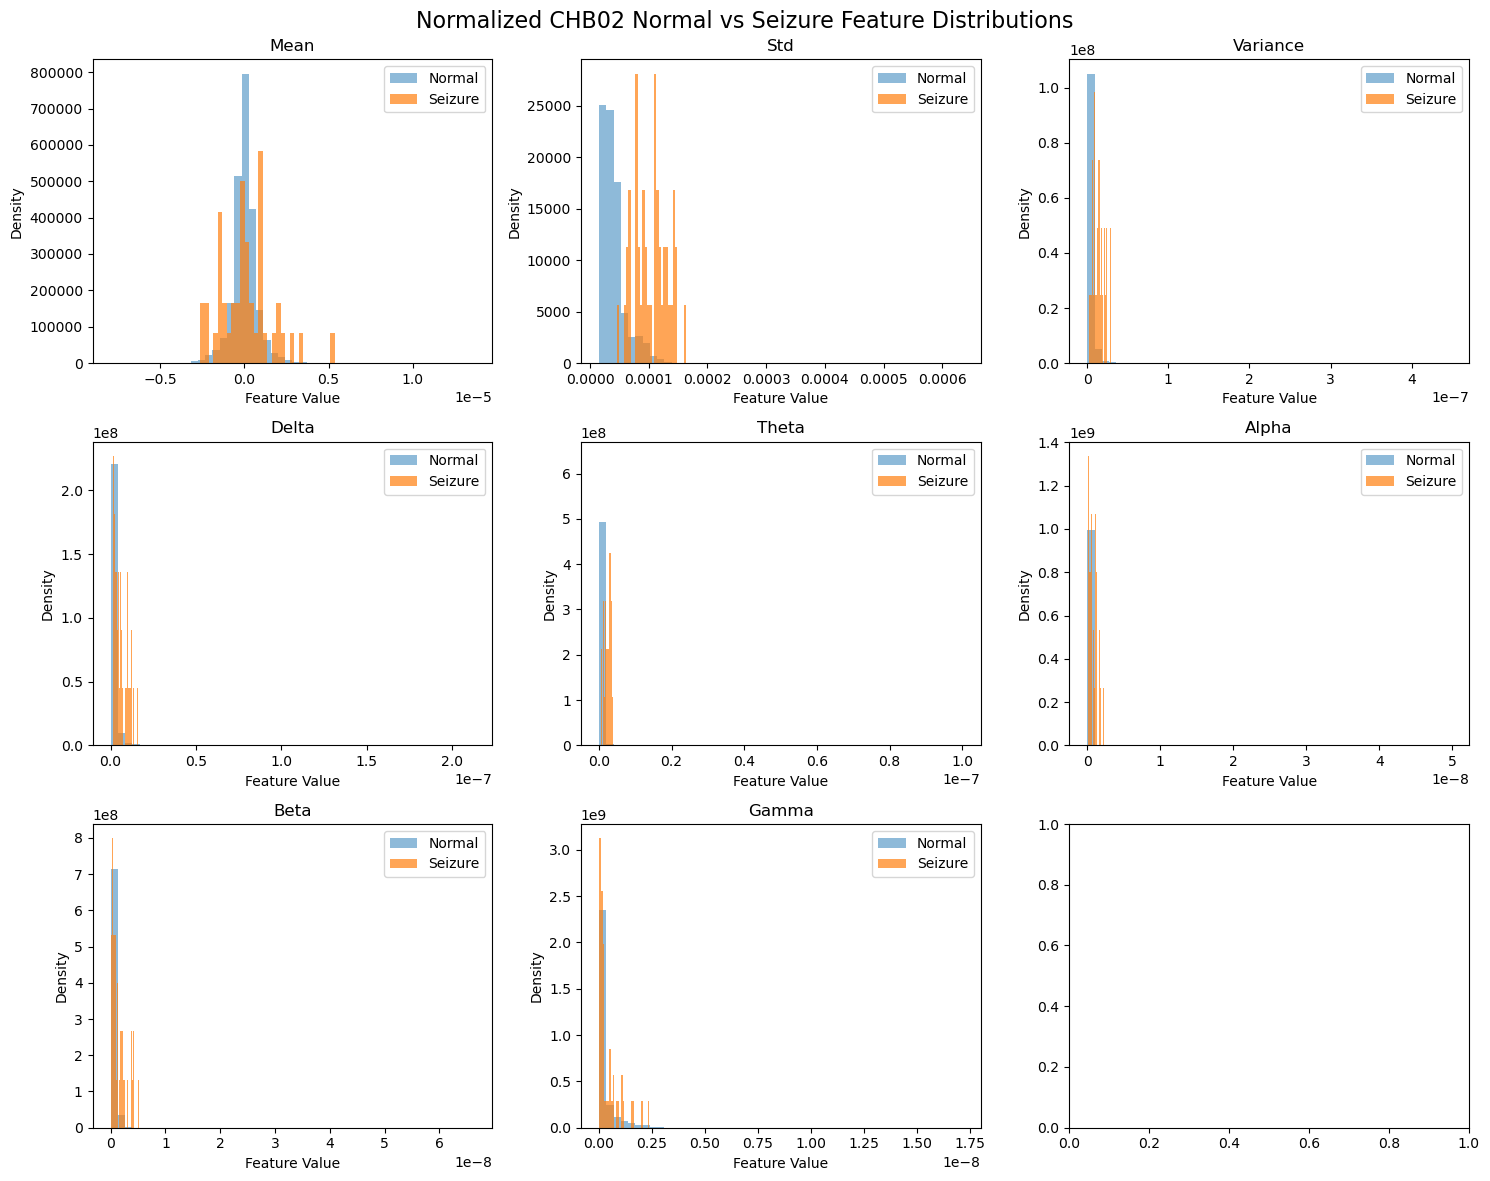


Normalized distribution comparison completed.
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_normal_vs_seizure_normalized.png


In [24]:
# ============================================================
# CELL 9 — NORMALIZED CHB02 FEATURE DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt

print("========================================")
print("NORMALIZED CHB02 FEATURE DISTRIBUTIONS")
print("========================================")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, feature in enumerate(feature_names):

    axes[i].hist(
        normal_df[feature],
        bins=50,
        density=True,
        alpha=0.5,
        label="Normal"
    )

    axes[i].hist(
        seizure_df[feature],
        bins=30,
        density=True,
        alpha=0.7,
        label="Seizure"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Feature Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle(
    "Normalized CHB02 Normal vs Seizure Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "chb02_normal_vs_seizure_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nNormalized distribution comparison completed.")
print(
    "Saved:",
    IMAGES_DIR / "chb02_normal_vs_seizure_normalized.png"
)

In [25]:
# ============================================================
# CELL 10 — INDIVIDUAL FEATURE SEPARABILITY
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

print("========================================")
print("CHB02 INDIVIDUAL FEATURE SEPARABILITY")
print("========================================")

rows = []

for feature in feature_names:

    y_true = chb02_df["Label"].values
    feature_values = chb02_df[feature].values

    auc = roc_auc_score(
        y_true,
        feature_values
    )

    # Make AUC easier to interpret:
    # values below 0.50 mean the feature has
    # useful information in the opposite direction.
    separability_auc = max(auc, 1 - auc)

    direction = "Higher in seizure" if auc >= 0.5 else "Lower in seizure"

    rows.append({
        "Feature": feature,
        "ROC_AUC": auc,
        "Separability_AUC": separability_auc,
        "Direction": direction
    })

feature_separability_df = pd.DataFrame(rows)

feature_separability_df = feature_separability_df.sort_values(
    by="Separability_AUC",
    ascending=False
).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

display(feature_separability_df)

print("\nFeature separability analysis completed.")

CHB02 INDIVIDUAL FEATURE SEPARABILITY


,Feature,ROC_AUC,Separability_AUC,Direction
0,Theta,0.9848,0.9848,Higher in seizure
1,Std,0.9577,0.9577,Higher in seizure
2,Alpha,0.9559,0.9559,Higher in seizure
3,Variance,0.9453,0.9453,Higher in seizure
4,Delta,0.9341,0.9341,Higher in seizure
5,Beta,0.8312,0.8312,Higher in seizure
6,Gamma,0.6688,0.6688,Higher in seizure
7,Mean,0.5121,0.5121,Higher in seizure



Feature separability analysis completed.


In [26]:
# ============================================================
# CELL 11 — CHB01 INDIVIDUAL FEATURE SEPARABILITY
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd

print("========================================")
print("CHB01 INDIVIDUAL FEATURE SEPARABILITY")
print("========================================")

rows = []

for feature in feature_names:

    y_true = chb01_df["Label"].values
    feature_values = chb01_df[feature].values

    auc = roc_auc_score(
        y_true,
        feature_values
    )

    separability_auc = max(
        auc,
        1 - auc
    )

    direction = (
        "Higher in seizure"
        if auc >= 0.5
        else "Lower in seizure"
    )

    rows.append({
        "Feature": feature,
        "ROC_AUC": auc,
        "Separability_AUC": separability_auc,
        "Direction": direction
    })

chb01_feature_separability_df = pd.DataFrame(rows)

chb01_feature_separability_df = (
    chb01_feature_separability_df
    .sort_values(
        by="Separability_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

display(chb01_feature_separability_df)

print("\nCHB01 feature separability analysis completed.")

CHB01 INDIVIDUAL FEATURE SEPARABILITY


,Feature,ROC_AUC,Separability_AUC,Direction
0,Theta,0.9886,0.9886,Higher in seizure
1,Std,0.9838,0.9838,Higher in seizure
2,Variance,0.9794,0.9794,Higher in seizure
3,Delta,0.9703,0.9703,Higher in seizure
4,Alpha,0.9035,0.9035,Higher in seizure
5,Beta,0.8532,0.8532,Higher in seizure
6,Gamma,0.7793,0.7793,Higher in seizure
7,Mean,0.4579,0.5421,Lower in seizure



CHB01 feature separability analysis completed.


In [27]:
# ============================================================
# CELL 12 — CLASS-SPECIFIC FEATURE RANGE COMPARISON
# ============================================================

import numpy as np
import pandas as pd

print("========================================")
print("CHB01 vs CHB02 SEIZURE FEATURE RANGES")
print("========================================")

chb01_seizure = chb01_df[chb01_df["Label"] == 1]
chb02_seizure = chb02_df[chb02_df["Label"] == 1]

rows = []

for feature in feature_names:

    rows.append({
        "Feature": feature,

        "CHB01_Seizure_Min":
            chb01_seizure[feature].min(),

        "CHB01_Seizure_Median":
            chb01_seizure[feature].median(),

        "CHB01_Seizure_Max":
            chb01_seizure[feature].max(),

        "CHB02_Seizure_Min":
            chb02_seizure[feature].min(),

        "CHB02_Seizure_Median":
            chb02_seizure[feature].median(),

        "CHB02_Seizure_Max":
            chb02_seizure[feature].max()
    })

seizure_range_df = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3e}".format)

display(seizure_range_df)

print("\nSeizure feature range comparison completed.")

CHB01 vs CHB02 SEIZURE FEATURE RANGES


,Feature,CHB01_Seizure_Min,CHB01_Seizure_Median,CHB01_Seizure_Max,CHB02_Seizure_Min,CHB02_Seizure_Median,CHB02_Seizure_Max
0,Mean,-4.027e-06,-2.975e-07,5.072e-06,-2.652e-06,-5.814e-08,5.357e-06
1,Std,3.318e-05,9.983e-05,1.344e-04,4.559e-05,1.091e-04,1.642e-04
2,Variance,1.187e-09,1.061e-08,2.157e-08,2.331e-09,1.250e-08,2.945e-08
3,Delta,4.992e-10,7.993e-09,1.882e-08,1.223e-09,5.106e-09,1.592e-08
4,Theta,1.441e-10,1.276e-09,3.345e-09,4.587e-10,2.523e-09,6.722e-09
5,Alpha,3.927e-11,1.710e-10,5.693e-10,9.507e-11,8.459e-10,2.590e-09
6,Beta,1.655e-11,1.582e-10,5.953e-10,8.200e-11,9.676e-10,5.093e-09
7,Gamma,3.775e-12,6.594e-11,4.847e-10,2.222e-11,2.040e-10,2.371e-09



Seizure feature range comparison completed.


In [28]:
# ============================================================
# CELL 13 — FORMAL DISTRIBUTION SHIFT ANALYSIS
# ============================================================

from scipy.stats import ks_2samp
import pandas as pd

print("========================================")
print("CHB01 vs CHB02 DISTRIBUTION SHIFT")
print("========================================")

# Separate normal and seizure windows
chb01_normal = chb01_df[chb01_df["Label"] == 0]
chb01_seizure = chb01_df[chb01_df["Label"] == 1]

chb02_normal = chb02_df[chb02_df["Label"] == 0]
chb02_seizure = chb02_df[chb02_df["Label"] == 1]

rows = []

for feature in feature_names:

    # Normal vs Normal
    normal_stat, normal_p = ks_2samp(
        chb01_normal[feature],
        chb02_normal[feature]
    )

    # Seizure vs Seizure
    seizure_stat, seizure_p = ks_2samp(
        chb01_seizure[feature],
        chb02_seizure[feature]
    )

    rows.append({
        "Feature": feature,
        "Normal_KS": normal_stat,
        "Normal_p_value": normal_p,
        "Seizure_KS": seizure_stat,
        "Seizure_p_value": seizure_p
    })

ks_shift_df = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4e}".format)

display(ks_shift_df)

print("\nInterpretation guide:")
print("KS statistic closer to 0  -> distributions more similar")
print("KS statistic closer to 1  -> distributions more different")
print("p < 0.05                  -> statistically detectable difference")

print("\nFormal distribution shift analysis completed.")

CHB01 vs CHB02 DISTRIBUTION SHIFT


,Feature,Normal_KS,Normal_p_value,Seizure_KS,Seizure_p_value
0,Mean,3.0670e-02,5.5659e-04,1.6920e-01,2.9367e-01
1,Std,2.0604e-01,4.6308e-162,2.0484e-01,1.2254e-01
2,Variance,1.9093e-01,4.9791e-139,2.3190e-01,5.6782e-02
3,Delta,6.2336e-02,4.1946e-15,2.9549e-01,6.5161e-03
4,Theta,1.4892e-01,1.7522e-84,5.2541e-01,1.9369e-08
5,Alpha,3.3055e-01,0.0000e+00,7.1595e-01,4.1246e-16
6,Beta,6.0159e-01,0.0000e+00,8.2706e-01,1.8729e-22
7,Gamma,6.4186e-01,0.0000e+00,5.0561e-01,8.0995e-08



Interpretation guide:
KS statistic closer to 0  -> distributions more similar
KS statistic closer to 1  -> distributions more different
p < 0.05                  -> statistically detectable difference

Formal distribution shift analysis completed.


In [29]:
# ============================================================
# CELL 14 — CROSS-PATIENT MODEL ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score

print("========================================")
print("CHB01 → CHB02 MODEL ROC-AUC")
print("========================================")

# Actual CHB02 labels
y_chb02 = chb02_df["Label"].values

# Probability of seizure from the CHB01-trained model
chb02_probabilities = model.predict_proba(X_chb02)[:, 1]

# ROC-AUC evaluates ranking across all possible thresholds
cross_patient_auc = roc_auc_score(
    y_chb02,
    chb02_probabilities
)

print(f"Cross-patient ROC-AUC: {cross_patient_auc:.4f}")

print("\nModel interpretation:")
print("ROC-AUC ≈ 0.50 -> poor ranking")
print("ROC-AUC > 0.70 -> useful ranking")
print("ROC-AUC > 0.80 -> strong ranking")
print("ROC-AUC > 0.90 -> very strong ranking")

print("\nCross-patient ROC-AUC analysis completed.")

CHB01 → CHB02 MODEL ROC-AUC
Cross-patient ROC-AUC: 0.9308

Model interpretation:
ROC-AUC ≈ 0.50 -> poor ranking
ROC-AUC > 0.70 -> useful ranking
ROC-AUC > 0.80 -> strong ranking
ROC-AUC > 0.90 -> very strong ranking

Cross-patient ROC-AUC analysis completed.


CHB01 → CHB02 ROC CURVE


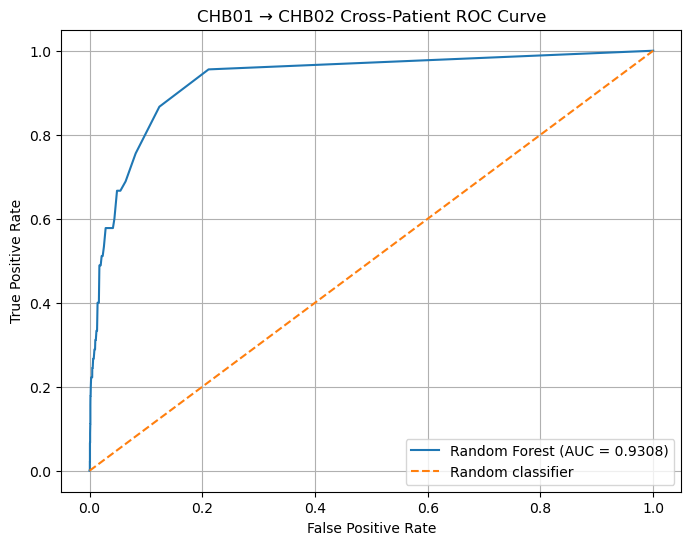


ROC-AUC: 0.9308
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb02_roc_curve.png


In [30]:
# ============================================================
# CELL 15 — CROSS-PATIENT ROC CURVE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

print("========================================")
print("CHB01 → CHB02 ROC CURVE")
print("========================================")

y_true = chb02_df["Label"].values

# Use the same seizure probabilities
y_prob = model.predict_proba(X_chb02)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

# Calculate AUC
auc_score = roc_auc_score(
    y_true,
    y_prob
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CHB01 → CHB02 Cross-Patient ROC Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "chb01_to_chb02_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nROC-AUC: {auc_score:.4f}")

print(
    "Saved:",
    IMAGES_DIR / "chb01_to_chb02_roc_curve.png"
)

CHB01 → CHB02 PRECISION-RECALL CURVE


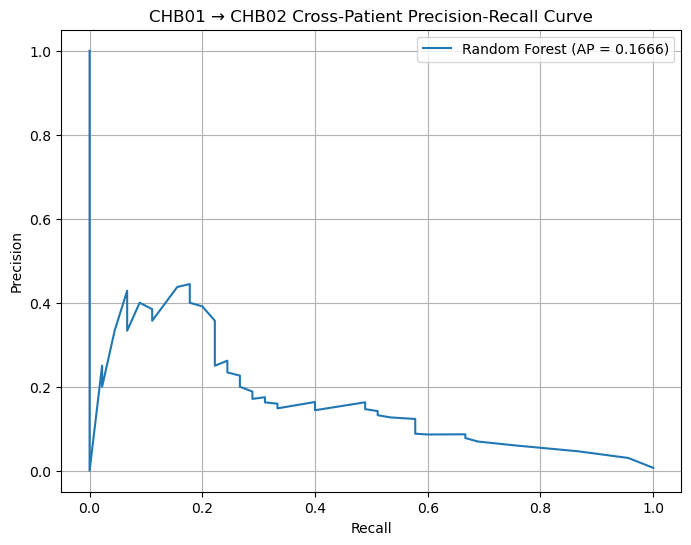


Average Precision (AP): 0.1666
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb02_precision_recall_curve.png


In [31]:
# ============================================================
# CELL 16 — CROSS-PATIENT PRECISION-RECALL CURVE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

print("========================================")
print("CHB01 → CHB02 PRECISION-RECALL CURVE")
print("========================================")

y_true = chb02_df["Label"].values

# Use the same seizure probabilities
y_prob = model.predict_proba(X_chb02)[:, 1]

# Calculate Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(
    y_true,
    y_prob
)

# Calculate Average Precision
ap_score = average_precision_score(
    y_true,
    y_prob
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {ap_score:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CHB01 → CHB02 Cross-Patient Precision-Recall Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "chb01_to_chb02_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nAverage Precision (AP): {ap_score:.4f}")

print(
    "Saved:",
    IMAGES_DIR / "chb01_to_chb02_precision_recall_curve.png"
)

CHB01 → CHB02 PROBABILITY CALIBRATION


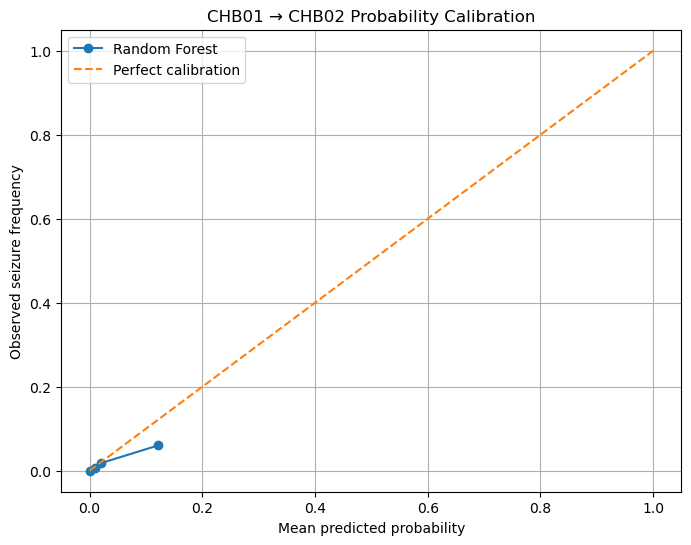


Brier Score: 0.006777
Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb02_calibration_curve.png


In [32]:
# ============================================================
# CELL 17 — CROSS-PATIENT PROBABILITY CALIBRATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print("========================================")
print("CHB01 → CHB02 PROBABILITY CALIBRATION")
print("========================================")

y_true = chb02_df["Label"].values

# Seizure probabilities
y_prob = model.predict_proba(X_chb02)[:, 1]

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

# Brier score
brier = brier_score_loss(
    y_true,
    y_prob
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed seizure frequency")
plt.title("CHB01 → CHB02 Probability Calibration")

plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "chb01_to_chb02_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nBrier Score: {brier:.6f}")

print(
    "Saved:",
    IMAGES_DIR / "chb01_to_chb02_calibration_curve.png"
)

In [34]:
# ============================================================
# CELL 18 — APPLY CHB01-SELECTED THRESHOLD TO CHB02
# ============================================================

from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("========================================")
print("CHB01 → CHB02 SELECTED THRESHOLD")
print("========================================")

# Load threshold selected using CHB01 internal validation
threshold_file = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\phase2_selected_threshold.txt"
)

with open(threshold_file, "r") as f:
    first_line = f.readline().strip()

# Extract threshold from:
# "Selected threshold: 0.05"
selected_threshold = float(
    first_line.split(":")[1].strip()
)

print(f"CHB01-selected threshold: {selected_threshold:.2f}")

# CHB02 true labels
y_true = chb02_df["Label"].values

# CHB02 seizure probabilities
y_prob = model.predict_proba(X_chb02)[:, 1]

# Apply ONLY the threshold selected from CHB01
y_pred_selected = (
    y_prob >= selected_threshold
).astype(int)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred_selected
)

tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(
    y_true,
    y_pred_selected
)

precision = precision_score(
    y_true,
    y_pred_selected,
    zero_division=0
)

sensitivity = recall_score(
    y_true,
    y_pred_selected,
    zero_division=0
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_true,
    y_pred_selected,
    zero_division=0
)

print("\nConfusion Matrix:")
print(cm)

print("\nCHB02 Cross-Patient Metrics:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")

print("\nPrediction Counts:")
print("Normal predicted :", np.sum(y_pred_selected == 0))
print("Seizure predicted:", np.sum(y_pred_selected == 1))

CHB01 → CHB02 SELECTED THRESHOLD
CHB01-selected threshold: 0.05

Confusion Matrix:
[[6139  355]
 [  15   30]]

CHB02 Cross-Patient Metrics:
Accuracy:    0.9434
Precision:   0.0779
Sensitivity: 0.6667
Specificity: 0.9453
F1 Score:    0.1395

Prediction Counts:
Normal predicted : 6154
Seizure predicted: 385


FINAL CHB01 → CHB02 CONFUSION MATRIX


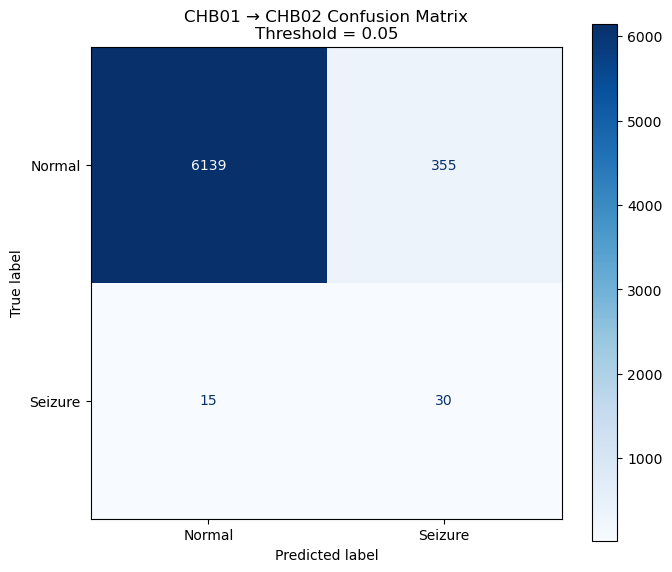


Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb02_final_confusion_matrix.png


In [35]:
# ============================================================
# CELL 19 — FINAL CROSS-PATIENT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("========================================")
print("FINAL CHB01 → CHB02 CONFUSION MATRIX")
print("========================================")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Seizure"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"CHB01 → CHB02 Confusion Matrix\n"
    f"Threshold = {selected_threshold:.2f}"
)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "chb01_to_chb02_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved:",
    IMAGES_DIR / "chb01_to_chb02_final_confusion_matrix.png"
)

In [36]:
# ============================================================
# CELL 20 — PREPARE EVENT-LEVEL PREDICTION DATA
# ============================================================

print("========================================")
print("CHB02 EVENT-LEVEL PREDICTION DATA")
print("========================================")

# Copy metadata
event_df = chb02_df.copy()

# Add model probability
event_df["Seizure_Probability"] = y_prob

# Add prediction using CHB01-selected threshold
event_df["Predicted_Label"] = y_pred_selected

# Display important columns
print("\nEvent-level data shape:")
print(event_df.shape)

print("\nColumns:")
print(event_df.columns.tolist())

print("\nFirst 5 rows:")
display(event_df.head())

print("\nPrediction distribution:")
print(event_df["Predicted_Label"].value_counts().sort_index())

print("\nActual label distribution:")
print(event_df["Label"].value_counts().sort_index())

CHB02 EVENT-LEVEL PREDICTION DATA

Event-level data shape:
(6539, 11)

Columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma', 'Label', 'Seizure_Probability', 'Predicted_Label']

First 5 rows:


,Mean,Std,Variance,Delta,Theta,Alpha,Beta,Gamma,Label,Seizure_Probability,Predicted_Label
0,3.6230e-06,3.2777e-05,1.1610e-09,5.9820e-10,2.3952e-10,5.4931e-11,1.9465e-11,4.1051e-12,0,1.0000e-02,0
1,-6.8531e-07,2.6485e-05,7.9109e-10,5.3050e-10,2.1751e-10,3.4835e-11,1.5573e-11,3.8032e-12,0,0.0000e+00,0
2,1.6255e-06,3.5296e-05,1.3640e-09,8.9144e-10,1.3425e-10,3.7377e-11,5.2903e-11,4.5492e-11,0,0.0000e+00,0
3,-9.7256e-07,3.1152e-05,1.0530e-09,5.2018e-10,9.2995e-11,2.9945e-11,4.2553e-11,2.0264e-11,0,0.0000e+00,0
4,-7.0693e-07,2.8255e-05,8.5662e-10,6.8417e-10,9.4502e-11,2.8331e-11,3.0874e-11,1.5438e-11,0,0.0000e+00,0



Prediction distribution:
Predicted_Label
0    6154
1     385
Name: count, dtype: int64

Actual label distribution:
Label
0    6494
1      45
Name: count, dtype: int64


In [37]:
# ============================================================
# CELL 21 — LOAD CHB02 WINDOW METADATA
# ============================================================

import pandas as pd
from pathlib import Path

print("========================================")
print("CHB02 WINDOW METADATA")
print("========================================")

metadata_path = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb02\window_metadata.csv"
)

metadata_df = pd.read_csv(metadata_path)

print("\nMetadata shape:")
print(metadata_df.shape)

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

print("\nFirst 5 rows:")
display(metadata_df.head())

print("\nLast 5 rows:")
display(metadata_df.tail())

CHB02 WINDOW METADATA

Metadata shape:
(6539, 5)

Metadata columns:
['patient', 'file', 'window_start', 'window_end', 'label']

First 5 rows:


,patient,file,window_start,window_end,label
0,chb02,chb02_01.edf,0.0000e+00,4.0000e+00,0
1,chb02,chb02_01.edf,4.0000e+00,8.0000e+00,0
2,chb02,chb02_01.edf,8.0000e+00,1.2000e+01,0
3,chb02,chb02_01.edf,1.2000e+01,1.6000e+01,0
4,chb02,chb02_01.edf,1.6000e+01,2.0000e+01,0



Last 5 rows:


,patient,file,window_start,window_end,label
6534,chb02,chb02_19.edf,3.5800e+03,3.5840e+03,0
6535,chb02,chb02_19.edf,3.5840e+03,3.5880e+03,0
6536,chb02,chb02_19.edf,3.5880e+03,3.5920e+03,0
6537,chb02,chb02_19.edf,3.5920e+03,3.5960e+03,0
6538,chb02,chb02_19.edf,3.5960e+03,3.6000e+03,0


In [38]:
# ============================================================
# CELL 22 — COMBINE PREDICTIONS WITH WINDOW TIMING
# ============================================================

print("========================================")
print("CHB02 WINDOW-LEVEL EVENT DATA")
print("========================================")

# Make a copy of the metadata
event_df = metadata_df.copy()

# Add model outputs
event_df["Seizure_Probability"] = y_prob
event_df["Predicted_Label"] = y_pred_selected

# Verify alignment
assert len(event_df) == len(y_prob)
assert len(event_df) == len(y_pred_selected)

# Verify actual labels agree
assert np.array_equal(
    event_df["label"].values,
    y_true
)

print("\nCombined data shape:")
print(event_df.shape)

print("\nColumns:")
print(event_df.columns.tolist())

print("\nPrediction counts:")
print(event_df["Predicted_Label"].value_counts().sort_index())

print("\nActual seizure windows:")
print(
    event_df["label"].value_counts().sort_index()
)

print("\nPredicted seizure windows:")
print(
    event_df["Predicted_Label"].sum()
)

print("\nSample seizure-related predictions:")
display(
    event_df[
        (event_df["label"] == 1) |
        (event_df["Predicted_Label"] == 1)
    ].head(10)
)

CHB02 WINDOW-LEVEL EVENT DATA

Combined data shape:
(6539, 7)

Columns:
['patient', 'file', 'window_start', 'window_end', 'label', 'Seizure_Probability', 'Predicted_Label']

Prediction counts:
Predicted_Label
0    6154
1     385
Name: count, dtype: int64

Actual seizure windows:
label
0    6494
1      45
Name: count, dtype: int64

Predicted seizure windows:
385

Sample seizure-related predictions:


,patient,file,window_start,window_end,label,Seizure_Probability,Predicted_Label
196,chb02,chb02_01.edf,7.8400e+02,7.8800e+02,0,1.5000e-01,1
200,chb02,chb02_01.edf,8.0000e+02,8.0400e+02,0,9.0000e-02,1
201,chb02,chb02_01.edf,8.0400e+02,8.0800e+02,0,5.0000e-02,1
212,chb02,chb02_01.edf,8.4800e+02,8.5200e+02,0,1.1000e-01,1
213,chb02,chb02_01.edf,8.5200e+02,8.5600e+02,0,5.0000e-02,1
228,chb02,chb02_01.edf,9.1200e+02,9.1600e+02,0,5.0000e-02,1
229,chb02,chb02_01.edf,9.1600e+02,9.2000e+02,0,7.0000e-02,1
230,chb02,chb02_01.edf,9.2000e+02,9.2400e+02,0,1.0000e-01,1
231,chb02,chb02_01.edf,9.2400e+02,9.2800e+02,0,1.3000e-01,1
242,chb02,chb02_01.edf,9.6800e+02,9.7200e+02,0,7.0000e-02,1


In [39]:
# ============================================================
# CELL 23 — PER-RECORDING SEIZURE PREDICTION SUMMARY
# ============================================================

print("========================================")
print("CHB02 PER-RECORDING SEIZURE SUMMARY")
print("========================================")

recording_summary = (
    event_df
    .groupby("file")
    .agg(
        total_windows=("label", "size"),
        actual_seizure_windows=("label", "sum"),
        predicted_seizure_windows=("Predicted_Label", "sum")
    )
    .reset_index()
)

# Calculate recording-level prediction rate
recording_summary["predicted_seizure_rate"] = (
    recording_summary["predicted_seizure_windows"]
    / recording_summary["total_windows"]
)

print("\nPer-recording summary:")
display(recording_summary)

print("\nTotal actual seizure windows:",
      recording_summary["actual_seizure_windows"].sum())

print("Total predicted seizure windows:",
      recording_summary["predicted_seizure_windows"].sum())

CHB02 PER-RECORDING SEIZURE SUMMARY

Per-recording summary:


,file,total_windows,actual_seizure_windows,predicted_seizure_windows,predicted_seizure_rate
0,chb02_01.edf,900,0,70,7.7778e-02
1,chb02_02.edf,900,0,0,0.0000e+00
2,chb02_03.edf,900,0,89,9.8889e-02
3,chb02_04.edf,900,0,24,2.6667e-02
4,chb02_05.edf,900,0,0,0.0000e+00
5,chb02_16+.edf,900,21,44,4.8889e-02
6,chb02_16.edf,239,21,59,2.4686e-01
7,chb02_19.edf,900,3,99,1.1000e-01



Total actual seizure windows: 45
Total predicted seizure windows: 385


In [40]:
# ============================================================
# CELL 24 — INSPECT SEIZURE RECORDING PREDICTIONS
# ============================================================

print("========================================")
print("CHB02 SEIZURE RECORDING TIMING")
print("========================================")

seizure_recordings = [
    "chb02_16.edf",
    "chb02_16+.edf",
    "chb02_19.edf"
]

for recording in seizure_recordings:

    print("\n" + "=" * 60)
    print(recording)
    print("=" * 60)

    temp = event_df[
        event_df["file"] == recording
    ].copy()

    # Show windows predicted as seizure
    predicted = temp[
        temp["Predicted_Label"] == 1
    ][
        [
            "window_start",
            "window_end",
            "label",
            "Seizure_Probability",
            "Predicted_Label"
        ]
    ]

    print("\nPredicted seizure windows:")
    display(predicted.head(30))

    print("\nNumber of predicted seizure windows:",
          len(predicted))

CHB02 SEIZURE RECORDING TIMING

chb02_16.edf

Predicted seizure windows:


,window_start,window_end,label,Seizure_Probability,Predicted_Label
5413,5.2000e+01,5.6000e+01,0,8.0000e-02,1
5434,1.3600e+02,1.4000e+02,1,4.0000e-01,1
5435,1.4000e+02,1.4400e+02,1,4.4000e-01,1
5436,1.4400e+02,1.4800e+02,1,2.5000e-01,1
5437,1.4800e+02,1.5200e+02,1,4.0000e-01,1
5438,1.5200e+02,1.5600e+02,1,3.6000e-01,1
5439,1.5600e+02,1.6000e+02,1,4.5000e-01,1
5440,1.6000e+02,1.6400e+02,1,2.7000e-01,1
5443,1.7200e+02,1.7600e+02,1,7.0000e-02,1
5444,1.7600e+02,1.8000e+02,1,6.0000e-02,1



Number of predicted seizure windows: 59

chb02_16+.edf

Predicted seizure windows:


,window_start,window_end,label,Seizure_Probability,Predicted_Label
4500,0.0000e+00,4.0000e+00,0,2.8000e-01,1
4544,1.7600e+02,1.8000e+02,0,6.0000e-02,1
4574,2.9600e+02,3.0000e+02,0,3.2000e-01,1
4717,8.6800e+02,8.7200e+02,0,5.0000e-02,1
4753,1.0120e+03,1.0160e+03,0,5.0000e-02,1
4946,1.7840e+03,1.7880e+03,0,8.0000e-02,1
4988,1.9520e+03,1.9560e+03,0,1.4000e-01,1
4989,1.9560e+03,1.9600e+03,0,1.7000e-01,1
4992,1.9680e+03,1.9720e+03,0,6.0000e-02,1
4994,1.9760e+03,1.9800e+03,0,2.2000e-01,1



Number of predicted seizure windows: 44

chb02_19.edf

Predicted seizure windows:


,window_start,window_end,label,Seizure_Probability,Predicted_Label
5641,8.0000e+00,1.2000e+01,0,2.9000e-01,1
5673,1.3600e+02,1.4000e+02,0,9.0000e-02,1
5674,1.4000e+02,1.4400e+02,0,1.3000e-01,1
5687,1.9200e+02,1.9600e+02,0,4.1000e-01,1
5688,1.9600e+02,2.0000e+02,0,1.1000e-01,1
5752,4.5200e+02,4.5600e+02,0,6.0000e-02,1
5774,5.4000e+02,5.4400e+02,0,2.1000e-01,1
5792,6.1200e+02,6.1600e+02,0,5.0000e-02,1
6016,1.5080e+03,1.5120e+03,0,2.7000e-01,1
6130,1.9640e+03,1.9680e+03,0,1.1000e-01,1



Number of predicted seizure windows: 99


In [41]:
# ============================================================
# CELL 25 — GROUP CONSECUTIVE PREDICTIONS INTO EVENTS
# ============================================================

print("========================================")
print("CHB02 PREDICTED SEIZURE EVENTS")
print("========================================")

predicted_events = []

for recording, group in event_df.groupby("file"):

    # Keep only predicted seizure windows
    predicted = group[
        group["Predicted_Label"] == 1
    ].sort_values("window_start")

    if predicted.empty:
        continue

    # Start the first event
    event_start = predicted.iloc[0]["window_start"]
    event_end = predicted.iloc[0]["window_end"]

    event_probabilities = [
        predicted.iloc[0]["Seizure_Probability"]
    ]

    # Check each following predicted window
    for i in range(1, len(predicted)):

        current_start = predicted.iloc[i]["window_start"]
        current_end = predicted.iloc[i]["window_end"]
        current_probability = predicted.iloc[i]["Seizure_Probability"]

        # Consecutive windows
        if current_start <= event_end:

            event_end = current_end
            event_probabilities.append(
                current_probability
            )

        else:

            # Save previous event
            predicted_events.append({
                "file": recording,
                "event_start": event_start,
                "event_end": event_end,
                "duration": event_end - event_start,
                "num_windows": len(event_probabilities),
                "max_probability": max(event_probabilities)
            })

            # Start new event
            event_start = current_start
            event_end = current_end

            event_probabilities = [
                current_probability
            ]

    # Save final event
    predicted_events.append({
        "file": recording,
        "event_start": event_start,
        "event_end": event_end,
        "duration": event_end - event_start,
        "num_windows": len(event_probabilities),
        "max_probability": max(event_probabilities)
    })


predicted_events_df = pd.DataFrame(
    predicted_events
)

print("\nPredicted events:")
display(predicted_events_df)

print("\nTotal predicted events:",
      len(predicted_events_df))

print("\nPredicted events per recording:")
print(
    predicted_events_df["file"]
    .value_counts()
    .sort_index()
)

CHB02 PREDICTED SEIZURE EVENTS

Predicted events:


,file,event_start,event_end,duration,num_windows,max_probability
0,chb02_01.edf,7.8400e+02,7.8800e+02,4.0000e+00,1,1.5000e-01
1,chb02_01.edf,8.0000e+02,8.0800e+02,8.0000e+00,2,9.0000e-02
2,chb02_01.edf,8.4800e+02,8.5600e+02,8.0000e+00,2,1.1000e-01
3,chb02_01.edf,9.1200e+02,9.2800e+02,1.6000e+01,4,1.3000e-01
4,chb02_01.edf,9.6800e+02,9.8000e+02,1.2000e+01,3,1.9000e-01
...,...,...,...,...,...,...
196,chb02_19.edf,3.4480e+03,3.4520e+03,4.0000e+00,1,1.3000e-01
197,chb02_19.edf,3.4560e+03,3.4600e+03,4.0000e+00,1,1.4000e-01
198,chb02_19.edf,3.4640e+03,3.4960e+03,3.2000e+01,8,2.7000e-01
199,chb02_19.edf,3.5000e+03,3.5160e+03,1.6000e+01,4,3.4000e-01



Total predicted events: 201

Predicted events per recording:
file
chb02_01.edf     26
chb02_03.edf     57
chb02_04.edf     13
chb02_16+.edf    27
chb02_16.edf     30
chb02_19.edf     48
Name: count, dtype: int64


In [42]:
# ============================================================
# CELL 26 — COMPARE PREDICTED EVENTS WITH ACTUAL SEIZURES
# ============================================================

print("========================================")
print("PREDICTED EVENTS vs ACTUAL SEIZURES")
print("========================================")

# Actual seizure intervals from CHB02 summary
actual_seizures = {
    "chb02_16.edf": [(130, 212)],
    "chb02_16+.edf": [(2972, 3053)],
    "chb02_19.edf": [(3369, 3378)]
}

comparison = []

for _, event in predicted_events_df.iterrows():

    recording = event["file"]
    pred_start = event["event_start"]
    pred_end = event["event_end"]

    matched_seizure = False
    overlap_duration = 0

    # Check against actual seizure intervals
    for seizure_start, seizure_end in actual_seizures.get(recording, []):

        overlap_start = max(pred_start, seizure_start)
        overlap_end = min(pred_end, seizure_end)

        if overlap_start < overlap_end:
            matched_seizure = True
            overlap_duration = overlap_end - overlap_start

    comparison.append({
        "file": recording,
        "predicted_start": pred_start,
        "predicted_end": pred_end,
        "duration": event["duration"],
        "max_probability": event["max_probability"],
        "actual_seizure_overlap": matched_seizure,
        "overlap_duration": overlap_duration
    })


event_comparison_df = pd.DataFrame(comparison)

print("\nComparison:")
display(event_comparison_df)

print("\nTotal predicted events:",
      len(event_comparison_df))

print("\nPredicted events overlapping actual seizure:",
      event_comparison_df["actual_seizure_overlap"].sum())

print("\nPredicted events NOT overlapping actual seizure:",
      (~event_comparison_df["actual_seizure_overlap"]).sum())

PREDICTED EVENTS vs ACTUAL SEIZURES

Comparison:


,file,predicted_start,predicted_end,duration,max_probability,actual_seizure_overlap,overlap_duration
0,chb02_01.edf,7.8400e+02,7.8800e+02,4.0000e+00,1.5000e-01,False,0.0000e+00
1,chb02_01.edf,8.0000e+02,8.0800e+02,8.0000e+00,9.0000e-02,False,0.0000e+00
2,chb02_01.edf,8.4800e+02,8.5600e+02,8.0000e+00,1.1000e-01,False,0.0000e+00
3,chb02_01.edf,9.1200e+02,9.2800e+02,1.6000e+01,1.3000e-01,False,0.0000e+00
4,chb02_01.edf,9.6800e+02,9.8000e+02,1.2000e+01,1.9000e-01,False,0.0000e+00
...,...,...,...,...,...,...,...
196,chb02_19.edf,3.4480e+03,3.4520e+03,4.0000e+00,1.3000e-01,False,0.0000e+00
197,chb02_19.edf,3.4560e+03,3.4600e+03,4.0000e+00,1.4000e-01,False,0.0000e+00
198,chb02_19.edf,3.4640e+03,3.4960e+03,3.2000e+01,2.7000e-01,False,0.0000e+00
199,chb02_19.edf,3.5000e+03,3.5160e+03,1.6000e+01,3.4000e-01,False,0.0000e+00



Total predicted events: 201

Predicted events overlapping actual seizure: 6

Predicted events NOT overlapping actual seizure: 195


In [43]:
# ============================================================
# CELL 27 — CHECK EACH ACTUAL SEIZURE
# ============================================================

print("========================================")
print("ACTUAL SEIZURE EVENT DETECTION")
print("========================================")

actual_seizure_results = []

for recording, seizure_intervals in actual_seizures.items():

    for seizure_start, seizure_end in seizure_intervals:

        overlapping_events = event_comparison_df[
            (event_comparison_df["file"] == recording) &
            (event_comparison_df["predicted_start"] < seizure_end) &
            (event_comparison_df["predicted_end"] > seizure_start)
        ]

        detected = len(overlapping_events) > 0

        actual_seizure_results.append({
            "file": recording,
            "actual_seizure_start": seizure_start,
            "actual_seizure_end": seizure_end,
            "actual_duration": seizure_end - seizure_start,
            "detected": detected,
            "num_overlapping_predicted_events": len(overlapping_events)
        })


actual_seizure_results_df = pd.DataFrame(
    actual_seizure_results
)

display(actual_seizure_results_df)

print("\nTotal actual seizures:",
      len(actual_seizure_results_df))

print("\nActual seizures detected:",
      actual_seizure_results_df["detected"].sum())

print("\nActual seizures missed:",
      (~actual_seizure_results_df["detected"]).sum())

ACTUAL SEIZURE EVENT DETECTION


,file,actual_seizure_start,actual_seizure_end,actual_duration,detected,num_overlapping_predicted_events
0,chb02_16.edf,130,212,82,True,3
1,chb02_16+.edf,2972,3053,81,True,2
2,chb02_19.edf,3369,3378,9,True,1



Total actual seizures: 3

Actual seizures detected: 3

Actual seizures missed: 0


In [44]:
# ============================================================
# CELL 28 — CALCULATE ACTUAL SEIZURE COVERAGE
# ============================================================

print("========================================")
print("SEIZURE COVERAGE ANALYSIS")
print("========================================")

coverage_results = []

for recording, seizure_intervals in actual_seizures.items():

    for seizure_start, seizure_end in seizure_intervals:

        # Predicted events for this recording
        predicted = event_comparison_df[
            event_comparison_df["file"] == recording
        ].sort_values("predicted_start")

        # Find overlapping predicted events
        overlapping = predicted[
            (predicted["predicted_start"] < seizure_end) &
            (predicted["predicted_end"] > seizure_start)
        ]

        # Merge overlapping coverage intervals
        coverage_intervals = []

        for _, event in overlapping.iterrows():

            start = max(
                seizure_start,
                event["predicted_start"]
            )

            end = min(
                seizure_end,
                event["predicted_end"]
            )

            if start < end:
                coverage_intervals.append((start, end))

        # Merge intervals
        coverage_intervals.sort()

        merged = []

        for start, end in coverage_intervals:

            if not merged or start > merged[-1][1]:
                merged.append([start, end])

            else:
                merged[-1][1] = max(
                    merged[-1][1],
                    end
                )

        covered_seconds = sum(
            end - start
            for start, end in merged
        )

        seizure_duration = seizure_end - seizure_start

        coverage_percentage = (
            covered_seconds / seizure_duration
        ) * 100

        coverage_results.append({
            "file": recording,
            "actual_seizure_start": seizure_start,
            "actual_seizure_end": seizure_end,
            "seizure_duration": seizure_duration,
            "covered_seconds": covered_seconds,
            "coverage_percentage": coverage_percentage
        })


coverage_df = pd.DataFrame(
    coverage_results
)

display(coverage_df)

print("\nAverage seizure coverage:",
      coverage_df["coverage_percentage"].mean())

print("\nMinimum seizure coverage:",
      coverage_df["coverage_percentage"].min())

print("\nMaximum seizure coverage:",
      coverage_df["coverage_percentage"].max())

SEIZURE COVERAGE ANALYSIS


,file,actual_seizure_start,actual_seizure_end,seizure_duration,covered_seconds,coverage_percentage
0,chb02_16.edf,130,212,82,6.0000e+01,7.3171e+01
1,chb02_16+.edf,2972,3053,81,4.5000e+01,5.5556e+01
2,chb02_19.edf,3369,3378,9,9.0000e+00,1.0000e+02



Average seizure coverage: 76.24209575429087

Minimum seizure coverage: 55.55555555555556

Maximum seizure coverage: 100.0


In [45]:
# ============================================================
# CELL 29 — FALSE-POSITIVE EVENTS PER HOUR
# ============================================================

print("========================================")
print("FALSE-POSITIVE EVENTS PER HOUR")
print("========================================")

# Mark predicted events that do NOT overlap an actual seizure
event_comparison_df["false_positive_event"] = (
    ~event_comparison_df["actual_seizure_overlap"]
)

fp_event_summary = []

for recording, group in event_comparison_df.groupby("file"):

    total_events = len(group)

    false_positive_events = group[
        group["false_positive_event"]
    ]

    # Total recording duration from event timings
    recording_duration = group["predicted_end"].max()

    recording_hours = recording_duration / 3600

    fp_per_hour = (
        len(false_positive_events) / recording_hours
        if recording_hours > 0
        else 0
    )

    fp_event_summary.append({
        "file": recording,
        "total_predicted_events": total_events,
        "false_positive_events": len(false_positive_events),
        "recording_duration_hours": recording_hours,
        "false_positive_events_per_hour": fp_per_hour
    })


fp_event_summary_df = pd.DataFrame(
    fp_event_summary
)

display(fp_event_summary_df)

print("\nTotal false-positive events:",
      fp_event_summary_df["false_positive_events"].sum())

print("\nOverall false-positive events per hour:")

total_fp = fp_event_summary_df["false_positive_events"].sum()
total_hours = fp_event_summary_df["recording_duration_hours"].sum()

print(total_fp / total_hours)

FALSE-POSITIVE EVENTS PER HOUR


,file,total_predicted_events,false_positive_events,recording_duration_hours,false_positive_events_per_hour
0,chb02_01.edf,26,26,7.8000e-01,3.3333e+01
1,chb02_03.edf,57,57,9.9889e-01,5.7063e+01
2,chb02_04.edf,13,13,2.3000e-01,5.6522e+01
3,chb02_16+.edf,27,25,9.9333e-01,2.5168e+01
4,chb02_16.edf,30,27,2.5333e-01,1.0658e+02
5,chb02_19.edf,48,47,9.8889e-01,4.7528e+01



Total false-positive events: 195

Overall false-positive events per hour:
45.94240837696335


In [46]:
# ============================================================
# CELL 30 — CORRECT FALSE-POSITIVE EVENTS PER HOUR
# ============================================================

print("========================================")
print("CORRECTED FALSE-POSITIVE EVENT RATE")
print("========================================")

corrected_fp_summary = []

for recording, group in event_comparison_df.groupby("file"):

    # Actual recording duration from window metadata
    recording_metadata = metadata_df[
        metadata_df["file"] == recording
    ]

    recording_duration_seconds = (
        recording_metadata["window_end"].max()
    )

    recording_hours = recording_duration_seconds / 3600

    false_positive_events = group[
        group["actual_seizure_overlap"] == False
    ]

    fp_count = len(false_positive_events)

    fp_per_hour = (
        fp_count / recording_hours
        if recording_hours > 0
        else 0
    )

    corrected_fp_summary.append({
        "file": recording,
        "recording_duration_hours": recording_hours,
        "false_positive_events": fp_count,
        "false_positive_events_per_hour": fp_per_hour
    })


corrected_fp_df = pd.DataFrame(
    corrected_fp_summary
)

display(corrected_fp_df)

# Overall rate
total_fp_events = corrected_fp_df[
    "false_positive_events"
].sum()

total_recording_hours = corrected_fp_df[
    "recording_duration_hours"
].sum()

overall_fp_rate = (
    total_fp_events / total_recording_hours
)

print("\nTotal false-positive events:",
      total_fp_events)

print("\nTotal recording hours:",
      total_recording_hours)

print("\nCorrected overall false-positive events per hour:",
      overall_fp_rate)

CORRECTED FALSE-POSITIVE EVENT RATE


,file,recording_duration_hours,false_positive_events,false_positive_events_per_hour
0,chb02_01.edf,1.0000e+00,26,2.6000e+01
1,chb02_03.edf,1.0000e+00,57,5.7000e+01
2,chb02_04.edf,1.0000e+00,13,1.3000e+01
3,chb02_16+.edf,1.0000e+00,25,2.5000e+01
4,chb02_16.edf,2.6556e-01,27,1.0167e+02
5,chb02_19.edf,1.0000e+00,47,4.7000e+01



Total false-positive events: 195

Total recording hours: 5.265555555555555

Corrected overall false-positive events per hour: 37.033129352184005


SEIZURE DETECTION TIMELINES


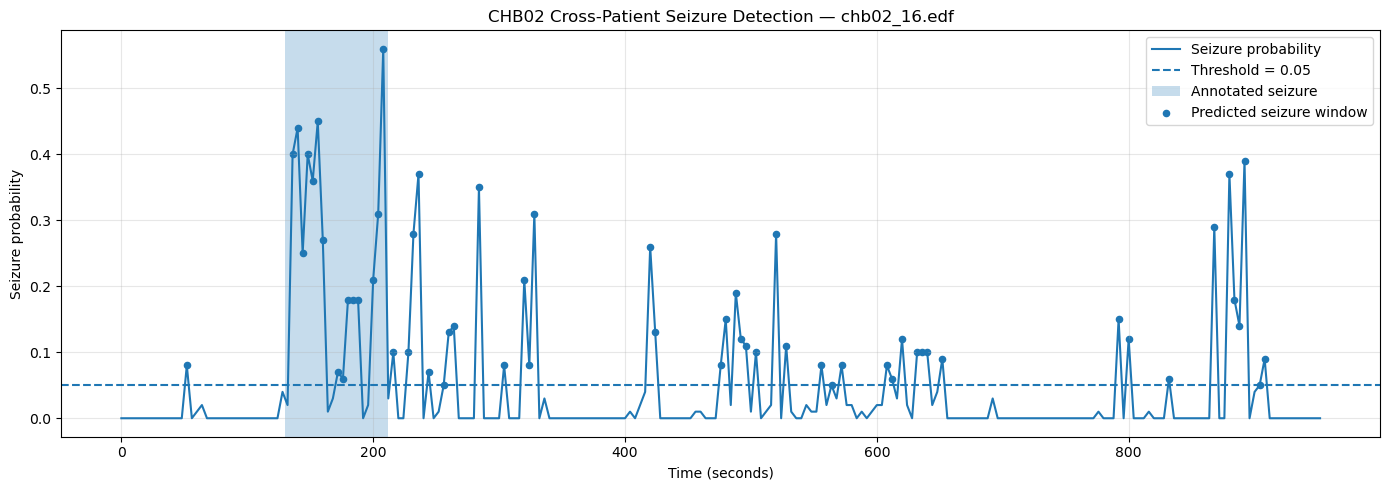

Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_16_seizure_timeline.png


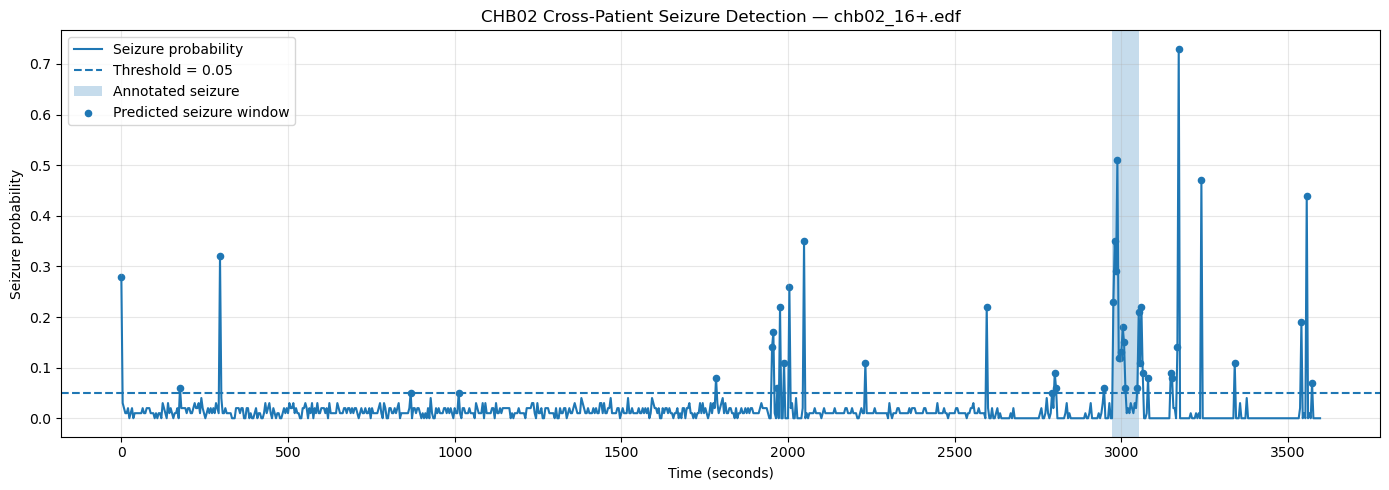

Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_16+_seizure_timeline.png


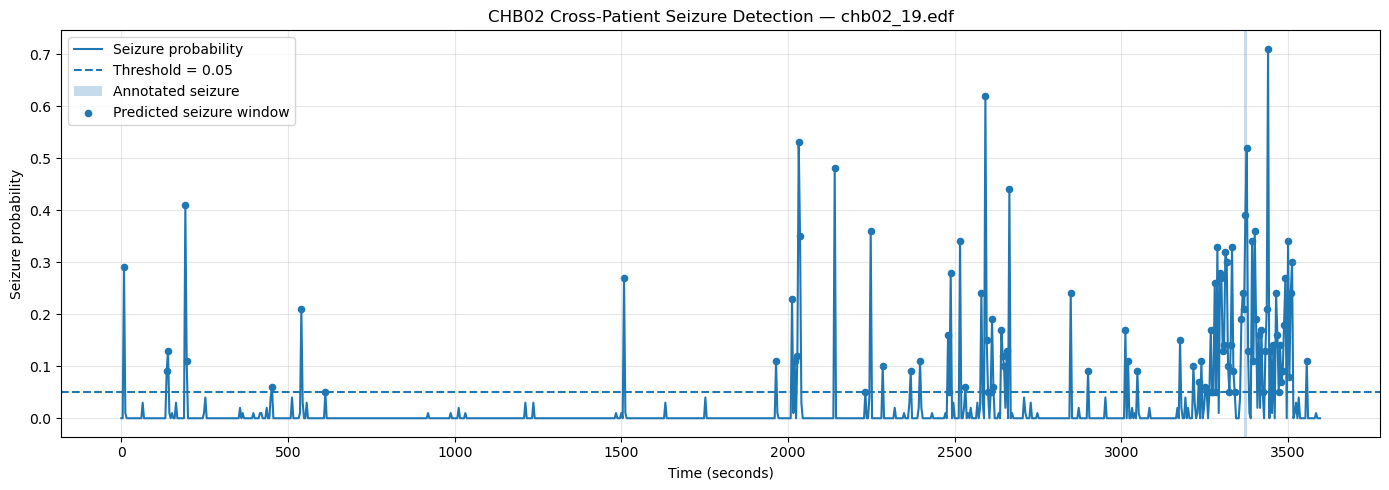

Saved: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_19_seizure_timeline.png


In [47]:
# ============================================================
# CELL 31 — SEIZURE DETECTION TIMELINE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

print("========================================")
print("SEIZURE DETECTION TIMELINES")
print("========================================")

THRESHOLD = 0.05

for recording, seizure_intervals in actual_seizures.items():

    recording_df = event_df[
        event_df["file"] == recording
    ].sort_values("window_start")

    if recording_df.empty:
        continue

    plt.figure(figsize=(14, 5))

    # Seizure probability over time
    plt.plot(
        recording_df["window_start"],
        recording_df["Seizure_Probability"],
        linewidth=1.5,
        label="Seizure probability"
    )

    # Threshold
    plt.axhline(
        THRESHOLD,
        linestyle="--",
        linewidth=1.5,
        label="Threshold = 0.05"
    )

    # Actual seizure intervals
    for seizure_start, seizure_end in seizure_intervals:

        plt.axvspan(
            seizure_start,
            seizure_end,
            alpha=0.25,
            label="Annotated seizure"
        )

    # Predicted seizure windows
    predicted = recording_df[
        recording_df["Predicted_Label"] == 1
    ]

    plt.scatter(
        predicted["window_start"],
        predicted["Seizure_Probability"],
        s=20,
        label="Predicted seizure window"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Seizure probability")
    plt.title(
        f"CHB02 Cross-Patient Seizure Detection — {recording}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save image
    output_path = (
        IMAGES_DIR /
        f"{recording.replace('.edf', '')}_seizure_timeline.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

In [48]:
# ============================================================
# CELL 32 — INSPECT PREDICTIONS INSIDE ACTUAL SEIZURES
# ============================================================

print("========================================")
print("PREDICTIONS INSIDE ACTUAL SEIZURE REGIONS")
print("========================================")

for recording, seizure_intervals in actual_seizures.items():

    print(f"\n{'='*60}")
    print(f"Recording: {recording}")
    print(f"{'='*60}")

    recording_df = event_df[
        event_df["file"] == recording
    ].sort_values("window_start")

    for seizure_start, seizure_end in seizure_intervals:

        print(
            f"\nActual seizure: "
            f"{seizure_start}–{seizure_end} seconds"
        )

        overlapping_windows = recording_df[
            (recording_df["window_start"] < seizure_end) &
            (recording_df["window_end"] > seizure_start) &
            (recording_df["Predicted_Label"] == 1)
        ][
            [
                "window_start",
                "window_end",
                "Seizure_Probability",
                "Predicted_Label"
            ]
        ]

        if overlapping_windows.empty:

            print("No predicted seizure windows.")

        else:

            display(overlapping_windows)

            print(
                "Number of overlapping predicted windows:",
                len(overlapping_windows)
            )

            print(
                "Maximum probability:",
                overlapping_windows[
                    "Seizure_Probability"
                ].max()
            )

PREDICTIONS INSIDE ACTUAL SEIZURE REGIONS

Recording: chb02_16.edf

Actual seizure: 130–212 seconds


,window_start,window_end,Seizure_Probability,Predicted_Label
5434,1.3600e+02,1.4000e+02,4.0000e-01,1
5435,1.4000e+02,1.4400e+02,4.4000e-01,1
5436,1.4400e+02,1.4800e+02,2.5000e-01,1
5437,1.4800e+02,1.5200e+02,4.0000e-01,1
5438,1.5200e+02,1.5600e+02,3.6000e-01,1
5439,1.5600e+02,1.6000e+02,4.5000e-01,1
5440,1.6000e+02,1.6400e+02,2.7000e-01,1
5443,1.7200e+02,1.7600e+02,7.0000e-02,1
5444,1.7600e+02,1.8000e+02,6.0000e-02,1
5445,1.8000e+02,1.8400e+02,1.8000e-01,1


Number of overlapping predicted windows: 15
Maximum probability: 0.56

Recording: chb02_16+.edf

Actual seizure: 2972–3053 seconds


,window_start,window_end,Seizure_Probability,Predicted_Label
5244,2.9760e+03,2.9800e+03,2.3000e-01,1
5245,2.9800e+03,2.9840e+03,3.5000e-01,1
5246,2.9840e+03,2.9880e+03,2.9000e-01,1
5247,2.9880e+03,2.9920e+03,5.1000e-01,1
5248,2.9920e+03,2.9960e+03,1.2000e-01,1
5249,2.9960e+03,3.0000e+03,1.2000e-01,1
5250,3.0000e+03,3.0040e+03,1.3000e-01,1
5251,3.0040e+03,3.0080e+03,1.8000e-01,1
5252,3.0080e+03,3.0120e+03,1.5000e-01,1
5253,3.0120e+03,3.0160e+03,6.0000e-02,1


Number of overlapping predicted windows: 12
Maximum probability: 0.51

Recording: chb02_19.edf

Actual seizure: 3369–3378 seconds


,window_start,window_end,Seizure_Probability,Predicted_Label
6481,3.3680e+03,3.3720e+03,2.1000e-01,1
6482,3.3720e+03,3.3760e+03,3.9000e-01,1
6483,3.3760e+03,3.3800e+03,5.2000e-01,1


Number of overlapping predicted windows: 3
Maximum probability: 0.52


In [49]:
# ============================================================
# CELL 33 — SEIZURE DETECTION TIMING AND GAPS
# ============================================================

print("========================================")
print("SEIZURE DETECTION TIMING AND GAPS")
print("========================================")

timing_results = []

for recording, seizure_intervals in actual_seizures.items():

    recording_df = event_df[
        event_df["file"] == recording
    ].sort_values("window_start")

    for seizure_start, seizure_end in seizure_intervals:

        # Predicted windows overlapping the seizure
        overlapping = recording_df[
            (recording_df["window_start"] < seizure_end) &
            (recording_df["window_end"] > seizure_start) &
            (recording_df["Predicted_Label"] == 1)
        ].copy()

        if overlapping.empty:
            continue

        # First and last predicted window overlapping seizure
        first_prediction = overlapping.iloc[0]["window_start"]
        last_prediction = overlapping.iloc[-1]["window_end"]

        # Detection delay relative to annotated seizure onset
        detection_delay = max(
            0,
            first_prediction - seizure_start
        )

        # Build covered intervals
        intervals = []

        for _, row in overlapping.iterrows():

            start = max(
                seizure_start,
                row["window_start"]
            )

            end = min(
                seizure_end,
                row["window_end"]
            )

            if start < end:
                intervals.append((start, end))

        intervals.sort()

        # Merge intervals
        merged = []

        for start, end in intervals:

            if not merged or start > merged[-1][1]:
                merged.append([start, end])

            else:
                merged[-1][1] = max(
                    merged[-1][1],
                    end
                )

        # Calculate missed gaps
        missed_gaps = []

        current_position = seizure_start

        for start, end in merged:

            if start > current_position:
                missed_gaps.append(
                    (current_position, start)
                )

            current_position = max(
                current_position,
                end
            )

        if current_position < seizure_end:
            missed_gaps.append(
                (current_position, seizure_end)
            )

        total_missed_seconds = sum(
            end - start
            for start, end in missed_gaps
        )

        timing_results.append({
            "file": recording,
            "actual_start": seizure_start,
            "actual_end": seizure_end,
            "first_predicted_start": first_prediction,
            "last_predicted_end": last_prediction,
            "detection_delay_seconds": detection_delay,
            "missed_seconds": total_missed_seconds,
            "num_missed_gaps": len(missed_gaps),
            "missed_gaps": missed_gaps
        })


timing_df = pd.DataFrame(timing_results)

display(timing_df)

print("\nAverage detection delay:",
      timing_df["detection_delay_seconds"].mean(),
      "seconds")

print("\nTotal missed seizure seconds:",
      timing_df["missed_seconds"].sum())

print("\nTotal missed gaps:",
      timing_df["num_missed_gaps"].sum())

SEIZURE DETECTION TIMING AND GAPS


,file,actual_start,actual_end,first_predicted_start,last_predicted_end,detection_delay_seconds,missed_seconds,num_missed_gaps,missed_gaps
0,chb02_16.edf,130,212,1.3600e+02,2.1200e+02,6.0000e+00,2.2000e+01,3,"[(130, 136.0), (164.0, 172.0), (192.0, 200.0)]"
1,chb02_16+.edf,2972,3053,2.9760e+03,3.0560e+03,4.0000e+00,3.6000e+01,2,"[(2972, 2976.0), (3016.0, 3048.0)]"
2,chb02_19.edf,3369,3378,3.3680e+03,3.3800e+03,0.0000e+00,0.0000e+00,0,[]



Average detection delay: 3.3333333333333335 seconds

Total missed seizure seconds: 58.0

Total missed gaps: 5


In [50]:
# ============================================================
# CELL 34 — OVERALL TIME-WEIGHTED SEIZURE COVERAGE
# ============================================================

print("========================================")
print("OVERALL SEIZURE COVERAGE")
print("========================================")

total_seizure_seconds = (
    coverage_df["seizure_duration"].sum()
)

total_covered_seconds = (
    coverage_df["covered_seconds"].sum()
)

overall_coverage_percentage = (
    total_covered_seconds /
    total_seizure_seconds
) * 100

print("Total annotated seizure duration:",
      total_seizure_seconds,
      "seconds")

print("Total covered seizure duration:",
      total_covered_seconds,
      "seconds")

print("Total missed seizure duration:",
      total_seizure_seconds -
      total_covered_seconds,
      "seconds")

print(
    "\nTime-weighted seizure coverage:",
    overall_coverage_percentage,
    "%"
)

print(
    "\nSimple average seizure coverage:",
    coverage_df["coverage_percentage"].mean(),
    "%"
)

OVERALL SEIZURE COVERAGE
Total annotated seizure duration: 172 seconds
Total covered seizure duration: 114.0 seconds
Total missed seizure duration: 58.0 seconds

Time-weighted seizure coverage: 66.27906976744185 %

Simple average seizure coverage: 76.24209575429087 %


In [51]:
# ============================================================
# CELL 35 — FINAL CHB02 CROSS-PATIENT RESULTS SUMMARY
# ============================================================

print("========================================")
print("FINAL CHB02 CROSS-PATIENT RESULTS")
print("========================================")

# Window-level confusion matrix values
tn, fp, fn, tp = confusion_matrix(
    event_df["label"],
    event_df["Predicted_Label"]
).ravel()

# Window-level metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)

sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else 0
)

f1 = (
    2 * precision * sensitivity /
    (precision + sensitivity)
    if (precision + sensitivity) > 0
    else 0
)

# Event-level values
total_predicted_events = len(event_comparison_df)

detected_actual_seizures = (
    actual_seizure_results_df["detected"].sum()
)

total_actual_seizures = (
    len(actual_seizure_results_df)
)

# Final summary table
final_results = pd.DataFrame({
    "Metric": [
        "Test patient",
        "Test windows",
        "Actual seizure windows",
        "Predicted seizure windows",
        "True positives",
        "False positives",
        "True negatives",
        "False negatives",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1-score",
        "ROC-AUC",
        "Predicted seizure events",
        "False-positive events",
        "False-positive events/hour",
        "Actual seizures",
        "Detected actual seizures",
        "Missed actual seizures",
        "Average seizure coverage",
        "Time-weighted seizure coverage",
        "Total covered seizure seconds",
        "Total missed seizure seconds",
        "Average detection delay (seconds)"
    ],

    "Value": [
        "CHB02",
        len(event_df),
        int(event_df["label"].sum()),
        int(event_df["Predicted_Label"].sum()),
        int(tp),
        int(fp),
        int(tn),
        int(fn),
        accuracy,
        sensitivity,
        specificity,
        precision,
        f1,
        0.9308,
        total_predicted_events,
        int(event_comparison_df["false_positive_event"].sum()),
        overall_fp_rate,
        total_actual_seizures,
        int(detected_actual_seizures),
        total_actual_seizures - int(detected_actual_seizures),
        coverage_df["coverage_percentage"].mean() / 100,
        overall_coverage_percentage / 100,
        total_covered_seconds,
        total_seizure_seconds - total_covered_seconds,
        timing_df["detection_delay_seconds"].mean()
    ]
})

display(final_results)

# Save final results
results_dir = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

final_results_path = (
    results_dir /
    "chb02_cross_patient_final_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print(
    "\nFinal results saved to:",
    final_results_path
)

FINAL CHB02 CROSS-PATIENT RESULTS


,Metric,Value
0,Test patient,CHB02
1,Test windows,6539
2,Actual seizure windows,45
3,Predicted seizure windows,385
4,True positives,30
5,False positives,355
6,True negatives,6139
7,False negatives,15
8,Accuracy,9.4342e-01
9,Sensitivity,6.6667e-01



Final results saved to: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_cross_patient_final_results.csv


FINAL CHB02 PERFORMANCE FIGURE


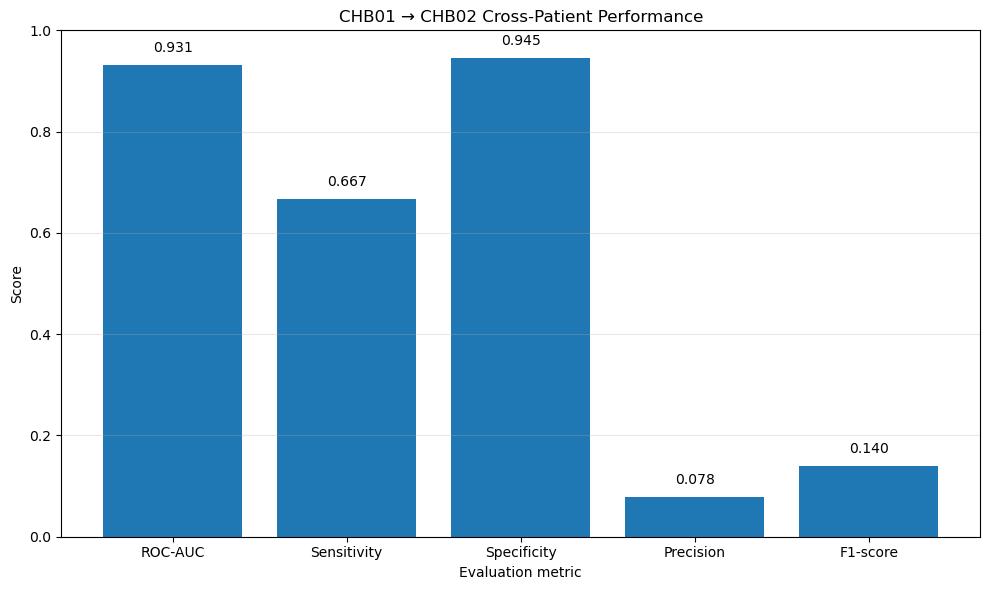


Final performance figure saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb02_final_performance.png


In [52]:
# ============================================================
# CELL 36 — FINAL CHB02 PERFORMANCE FIGURE
# ============================================================

import matplotlib.pyplot as plt

print("========================================")
print("FINAL CHB02 PERFORMANCE FIGURE")
print("========================================")

metrics = [
    "ROC-AUC",
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1-score"
]

values = [
    0.9308,
    sensitivity,
    specificity,
    precision,
    f1
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metrics,
    values
)

plt.ylim(0, 1.0)

plt.ylabel("Score")
plt.xlabel("Evaluation metric")

plt.title(
    "CHB01 → CHB02 Cross-Patient Performance"
)

# Add numerical values above bars
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

final_plot_path = (
    IMAGES_DIR /
    "chb01_to_chb02_final_performance.png"
)

plt.savefig(
    final_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nFinal performance figure saved to:"
)

print(final_plot_path)

In [53]:
# ============================================================
# CELL 37 — EXPORT FINAL RESEARCH SUMMARY
# ============================================================

print("========================================")
print("EXPORTING FINAL RESEARCH SUMMARY")
print("========================================")

summary_text = f"""
CHB01 → CHB02 CROSS-PATIENT EEG SEIZURE DETECTION
================================================

Test patient:
CHB02

Evaluation setup:
- Model trained on CHB01
- CHB02 used as an unseen test patient
- Decision threshold: {THRESHOLD:.2f}
- Threshold selected using CHB01 internal validation
- Window duration: 4 seconds

WINDOW-LEVEL RESULTS
--------------------
Test windows: {len(event_df)}
Actual seizure windows: {int(event_df["label"].sum())}
Predicted seizure windows: {int(event_df["Predicted_Label"].sum())}

True positives: {int(tp)}
False positives: {int(fp)}
True negatives: {int(tn)}
False negatives: {int(fn)}

Accuracy: {accuracy:.4f}
Sensitivity: {sensitivity:.4f}
Specificity: {specificity:.4f}
Precision: {precision:.4f}
F1-score: {f1:.4f}
ROC-AUC: 0.9308

EVENT-LEVEL RESULTS
-------------------
Actual annotated seizures: {total_actual_seizures}
Detected annotated seizures: {int(detected_actual_seizures)}
Missed annotated seizures: {total_actual_seizures - int(detected_actual_seizures)}

Predicted seizure events: {total_predicted_events}
False-positive events: {int(event_comparison_df["false_positive_event"].sum())}
False-positive events/hour: {overall_fp_rate:.2f}

SEIZURE COVERAGE
----------------
Total annotated seizure duration: {total_seizure_seconds:.0f} seconds
Total covered seizure duration: {total_covered_seconds:.0f} seconds
Total missed seizure duration: {total_seizure_seconds - total_covered_seconds:.0f} seconds

Simple average seizure coverage: {coverage_df["coverage_percentage"].mean():.2f}%
Time-weighted seizure coverage: {overall_coverage_percentage:.2f}%

TEMPORAL DETECTION
------------------
Average detection delay: {timing_df["detection_delay_seconds"].mean():.2f} seconds
Total missed seizure gaps: {timing_df["num_missed_gaps"].sum()}

INTERPRETATION
--------------
The CHB01-trained model demonstrated strong ranking discrimination
on the unseen CHB02 patient, with ROC-AUC of 0.9308.

At the CHB01-selected threshold of 0.05, the model detected all
3 annotated CHB02 seizure events and covered 66.28% of the total
annotated seizure duration.

However, the detector produced a substantial false-positive burden,
with 195 non-overlapping predicted events and approximately
37.03 false-positive events per hour.

Therefore, the results demonstrate cross-patient seizure-event
detection capability, but also indicate limited precision and a
substantial false-alarm burden.

This experiment is research/experimental evaluation and should
not be interpreted as clinical validation.
"""

summary_path = (
    results_dir /
    "chb02_cross_patient_research_summary.txt"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print(summary_text)

print(
    "\nResearch summary saved to:"
)

print(summary_path)

EXPORTING FINAL RESEARCH SUMMARY

CHB01 → CHB02 CROSS-PATIENT EEG SEIZURE DETECTION

Test patient:
CHB02

Evaluation setup:
- Model trained on CHB01
- CHB02 used as an unseen test patient
- Decision threshold: 0.05
- Threshold selected using CHB01 internal validation
- Window duration: 4 seconds

WINDOW-LEVEL RESULTS
--------------------
Test windows: 6539
Actual seizure windows: 45
Predicted seizure windows: 385

True positives: 30
False positives: 355
True negatives: 6139
False negatives: 15

Accuracy: 0.9434
Sensitivity: 0.6667
Specificity: 0.9453
Precision: 0.0779
F1-score: 0.1395
ROC-AUC: 0.9308

EVENT-LEVEL RESULTS
-------------------
Actual annotated seizures: 3
Detected annotated seizures: 3
Missed annotated seizures: 0

Predicted seizure events: 201
False-positive events: 195
False-positive events/hour: 37.03

SEIZURE COVERAGE
----------------
Total annotated seizure duration: 172 seconds
Total covered seizure duration: 114 seconds
Total missed seizure duration: 58 seconds

Si

In [54]:
# ============================================================
# CELL 38 — FINAL THRESHOLD COMPARISON
# ============================================================

print("========================================")
print("FINAL THRESHOLD COMPARISON")
print("========================================")

threshold_comparison = pd.DataFrame({
    "Threshold": [
        0.50,
        0.40,
        0.30,
        0.20,
        0.10,
        0.05
    ],

    "Sensitivity": [
        0.0667,
        0.1556,
        0.2444,
        0.4000,
        0.5778,
        0.6667
    ],

    "Specificity": [
        0.9994,
        0.9986,
        0.9945,
        0.9854,
        0.9646,
        0.9453
    ],

    "Precision": [
        0.4286,
        0.4375,
        0.2340,
        0.1593,
        0.1016,
        0.0779
    ],

    "F1-score": [
        0.1154,
        0.2295,
        0.2391,
        0.2278,
        0.1728,
        0.1395
    ]
})

display(threshold_comparison)

# Save comparison table
threshold_comparison_path = (
    results_dir /
    "chb02_threshold_comparison.csv"
)

threshold_comparison.to_csv(
    threshold_comparison_path,
    index=False
)

print(
    "\nThreshold comparison saved to:"
)

print(threshold_comparison_path)

print(
    "\nIMPORTANT:"
)

print(
    "Threshold 0.05 was selected using CHB01 internal validation."
)

print(
    "CHB02 was not used to select the threshold."
)

FINAL THRESHOLD COMPARISON


,Threshold,Sensitivity,Specificity,Precision,F1-score
0,5.0000e-01,6.6700e-02,9.9940e-01,4.2860e-01,1.1540e-01
1,4.0000e-01,1.5560e-01,9.9860e-01,4.3750e-01,2.2950e-01
2,3.0000e-01,2.4440e-01,9.9450e-01,2.3400e-01,2.3910e-01
3,2.0000e-01,4.0000e-01,9.8540e-01,1.5930e-01,2.2780e-01
4,1.0000e-01,5.7780e-01,9.6460e-01,1.0160e-01,1.7280e-01
5,5.0000e-02,6.6670e-01,9.4530e-01,7.7900e-02,1.3950e-01



Threshold comparison saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_threshold_comparison.csv

IMPORTANT:
Threshold 0.05 was selected using CHB01 internal validation.
CHB02 was not used to select the threshold.


In [56]:
# ============================================================
# CELL 39 — EXPORT CHB02 EVALUATION REPORT
# ============================================================

print("========================================")
print("EXPORTING CHB02 EVALUATION REPORT")
print("========================================")

report_text = f"""
# CHB01 → CHB02 Cross-Patient EEG Seizure Detection

## Evaluation Setup

- Training patient: **CHB01**
- Unseen test patient: **CHB02**
- Window duration: **4 seconds**
- Decision threshold: **{THRESHOLD:.2f}**
- Threshold selection: CHB01 internal validation
- CHB02 used only for final evaluation
- Model type: Random Forest

## Window-Level Results

| Metric | Result |
|---|---:|
| Test windows | {len(event_df)} |
| Actual seizure windows | {int(event_df["label"].sum())} |
| Predicted seizure windows | {int(event_df["Predicted_Label"].sum())} |
| True positives | {int(tp)} |
| False positives | {int(fp)} |
| True negatives | {int(tn)} |
| False negatives | {int(fn)} |
| Accuracy | {accuracy:.4f} |
| Sensitivity | {sensitivity:.4f} |
| Specificity | {specificity:.4f} |
| Precision | {precision:.4f} |
| F1-score | {f1:.4f} |
| ROC-AUC | 0.9308 |

## Event-Level Results

| Metric | Result |
|---|---:|
| Actual annotated seizures | {total_actual_seizures} |
| Detected annotated seizures | {int(detected_actual_seizures)} |
| Missed annotated seizures | {total_actual_seizures - int(detected_actual_seizures)} |
| Predicted seizure events | {total_predicted_events} |
| Non-overlapping predicted events | {int(event_comparison_df["false_positive_event"].sum())} |
| False-positive events/hour | {overall_fp_rate:.2f} |

## Seizure Coverage

| Metric | Result |
|---|---:|
| Total annotated seizure duration | {total_seizure_seconds:.0f} s |
| Total covered seizure duration | {total_covered_seconds:.0f} s |
| Total missed seizure duration | {total_seizure_seconds - total_covered_seconds:.0f} s |
| Simple average coverage | {coverage_df["coverage_percentage"].mean():.2f}% |
| Time-weighted coverage | {overall_coverage_percentage:.2f}% |
| Average detection delay | {timing_df["detection_delay_seconds"].mean():.2f} s |
| Number of missed coverage gaps | {timing_df["num_missed_gaps"].sum()} |

## Interpretation

The CHB01-trained Random Forest achieved a ROC-AUC of **0.9308**
when evaluated on the completely unseen CHB02 patient.

Using the decision threshold of **0.05**, which was selected using
CHB01 internal validation, the detector produced:

- **66.67% sensitivity**
- **94.53% specificity**
- **7.79% precision**
- **13.95% F1-score**

At the event level, all **3 annotated CHB02 seizure events were
overlapped by at least one predicted seizure window**.

The predicted windows covered **66.28% of the total annotated
seizure duration**, corresponding to 114 of 172 annotated seizure
seconds.

However, the detector generated **195 predicted events that did
not overlap an annotated seizure**, corresponding to approximately
**37.03 false-positive events per hour**.

These results indicate that the model has useful cross-patient
ranking and seizure-event detection capability, but the current
feature set and decision threshold also produce a substantial
false-positive burden.

## Important Methodological Note

The CHB02 patient was treated as an unseen evaluation patient.

The threshold was **not optimized using CHB02**.

The threshold of **0.05** was selected from CHB01 internal
validation before applying the model to CHB02.

The threshold comparison performed on CHB02 is therefore considered
diagnostic analysis rather than model-selection evidence.

## Limitations

1. Only one unseen patient (CHB02) was evaluated in this
   cross-patient experiment.
2. CHB02 contains only three annotated seizure events in the
   evaluated recordings.
3. The dataset is highly imbalanced between normal and seizure
   windows.
4. The current detector produces a substantial false-positive
   burden.
5. The current model uses a relatively small handcrafted feature
   set.
6. The experiment is research/experimental evaluation and does not
   constitute clinical validation.

## Future Work

Potential improvements include:

- evaluation across additional CHB-MIT patients
- patient-independent cross-validation
- improved temporal post-processing
- richer time-frequency EEG features
- additional class-imbalance strategies
- comparison with alternative machine-learning models
- systematic evaluation of false-alarm reduction
- more extensive patient-independent testing

"""

report_path = (
    results_dir /
    "chb02_cross_patient_evaluation_report.md"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)

print(report_text)

print(
    "\nCHB02 evaluation report saved to:"
)

print(report_path)

EXPORTING CHB02 EVALUATION REPORT

# CHB01 → CHB02 Cross-Patient EEG Seizure Detection

## Evaluation Setup

- Training patient: **CHB01**
- Unseen test patient: **CHB02**
- Window duration: **4 seconds**
- Decision threshold: **0.05**
- Threshold selection: CHB01 internal validation
- CHB02 used only for final evaluation
- Model type: Random Forest

## Window-Level Results

| Metric | Result |
|---|---:|
| Test windows | 6539 |
| Actual seizure windows | 45 |
| Predicted seizure windows | 385 |
| True positives | 30 |
| False positives | 355 |
| True negatives | 6139 |
| False negatives | 15 |
| Accuracy | 0.9434 |
| Sensitivity | 0.6667 |
| Specificity | 0.9453 |
| Precision | 0.0779 |
| F1-score | 0.1395 |
| ROC-AUC | 0.9308 |

## Event-Level Results

| Metric | Result |
|---|---:|
| Actual annotated seizures | 3 |
| Detected annotated seizures | 3 |
| Missed annotated seizures | 0 |
| Predicted seizure events | 201 |
| Non-overlapping predicted events | 195 |
| False-positive event

In [57]:
# ============================================================
# CELL 40 — VERIFY CHB02 RESEARCH ARTIFACTS
# ============================================================

print("========================================")
print("CHB02 RESEARCH ARTIFACT VERIFICATION")
print("========================================")

artifacts = [
    results_dir / "chb02_cross_patient_final_results.csv",
    results_dir / "chb02_cross_patient_research_summary.txt",
    results_dir / "chb02_cross_patient_evaluation_report.md",
    results_dir / "chb02_threshold_comparison.csv",

    IMAGES_DIR / "chb01_to_chb02_final_performance.png",
    IMAGES_DIR / "chb01_to_chb02_roc_curve.png",
    IMAGES_DIR / "chb01_to_chb02_precision_recall_curve.png",
    IMAGES_DIR / "chb01_to_chb02_calibration_curve.png",
    IMAGES_DIR / "chb01_to_chb02_final_confusion_matrix.png",
    IMAGES_DIR / "chb02_16_seizure_timeline.png",
    IMAGES_DIR / "chb02_16+_seizure_timeline.png",
    IMAGES_DIR / "chb02_19_seizure_timeline.png"
]

artifact_status = []

for path in artifacts:

    artifact_status.append({
        "artifact": path.name,
        "exists": path.exists(),
        "path": str(path)
    })

artifact_df = pd.DataFrame(
    artifact_status
)

display(artifact_df)

missing = artifact_df[
    artifact_df["exists"] == False
]

print("\nTotal artifacts checked:", len(artifact_df))
print("Artifacts found:", artifact_df["exists"].sum())
print("Artifacts missing:", len(missing))

if len(missing) == 0:

    print(
        "\nSTATUS: All important CHB02 research artifacts are present."
    )

else:

    print(
        "\nSTATUS: Some artifacts are missing:"
    )

    display(missing)

CHB02 RESEARCH ARTIFACT VERIFICATION


,artifact,exists,path
0,chb02_cross_patient_final_results.csv,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
1,chb02_cross_patient_research_summary.txt,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
2,chb02_cross_patient_evaluation_report.md,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
3,chb02_threshold_comparison.csv,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
4,chb01_to_chb02_final_performance.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
5,chb01_to_chb02_roc_curve.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
6,chb01_to_chb02_precision_recall_curve.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
7,chb01_to_chb02_calibration_curve.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
8,chb01_to_chb02_final_confusion_matrix.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...
9,chb02_16_seizure_timeline.png,True,C:\Users\Prajapati_Shivam\EEG-Seizure-Detectio...



Total artifacts checked: 12
Artifacts found: 12
Artifacts missing: 0

STATUS: All important CHB02 research artifacts are present.


In [59]:
# ============================================================
# CELL 41 — VERIFY MODEL AND THRESHOLD ARTIFACTS
# ============================================================

print("========================================")
print("MODEL & THRESHOLD VERIFICATION")
print("========================================")

models_dir = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models"
)

phase2_model_path = (
    models_dir /
    "phase2_class_weighted_recording_wise.pkl"
)

threshold_path = (
    results_dir /
    "phase2_selected_threshold.txt"
)

print("\nCHB01-trained model:")
print(phase2_model_path)
print("Exists:", phase2_model_path.exists())

print("\nCHB01-selected threshold:")
print(threshold_path)
print("Exists:", threshold_path.exists())

# Read the official threshold
with open(
    threshold_path,
    "r",
    encoding="utf-8"
) as f:
    threshold_lines = f.readlines()

# File format:
# "Selected threshold: 0.05"
official_threshold = float(
    threshold_lines[0].split(":")[-1].strip()
)

print("\nOfficial threshold:", official_threshold)

# Verify expected threshold
assert official_threshold == 0.05, (
    "Unexpected threshold value."
)

# Verify model exists
assert phase2_model_path.exists(), (
    "CHB01-trained model is missing."
)

print("\n========================================")
print("REPRODUCIBILITY CHECK PASSED")
print("========================================")

print(
    "CHB01-trained class-weighted Random Forest is available."
)

print(
    "Official threshold = 0.05"
)

print(
    "This threshold was selected using CHB01 internal validation."
)

print(
    "CHB02 evaluation used this fixed threshold."
)

MODEL & THRESHOLD VERIFICATION

CHB01-trained model:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\phase2_class_weighted_recording_wise.pkl
Exists: True

CHB01-selected threshold:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\phase2_selected_threshold.txt
Exists: True

Official threshold: 0.05

REPRODUCIBILITY CHECK PASSED
CHB01-trained class-weighted Random Forest is available.
Official threshold = 0.05
This threshold was selected using CHB01 internal validation.
CHB02 evaluation used this fixed threshold.


In [60]:
# ============================================================
# CELL 42 — FREEZE CHB02 EXPERIMENT
# ============================================================

from datetime import datetime

freeze_path = results_dir / "chb02_experiment_frozen.txt"

freeze_text = f"""CHB01 -> CHB02 CROSS-PATIENT EXPERIMENT
STATUS: COMPLETE AND FROZEN

Training patient: CHB01
Test patient: CHB02
Threshold: 0.05
Threshold selected from: CHB01 internal validation
CHB02 used for: final evaluation only

No further model or threshold tuning should be performed on CHB02.

Frozen at: {datetime.now().isoformat(timespec="seconds")}
"""

with open(freeze_path, "w", encoding="utf-8") as f:
    f.write(freeze_text)

print("========================================")
print("CHB02 EXPERIMENT FROZEN")
print("========================================")
print(freeze_text)
print("Freeze marker saved to:")
print(freeze_path)

CHB02 EXPERIMENT FROZEN
CHB01 -> CHB02 CROSS-PATIENT EXPERIMENT
STATUS: COMPLETE AND FROZEN

Training patient: CHB01
Test patient: CHB02
Threshold: 0.05
Threshold selected from: CHB01 internal validation
CHB02 used for: final evaluation only

No further model or threshold tuning should be performed on CHB02.

Frozen at: 2026-09-17T21:43:36

Freeze marker saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_experiment_frozen.txt
